# Algorytm genetyczny - Problem komiwojażera

#### Opracowanie: Kacper Książek, 417564
#### 11.05.2025

---

### Opis działania algorytmu 🧬

##### 0. Uwaga wstępna

Wszystkie trasy generowane są jako odległości pomiędzy punktami zawartymi w kwadracie o wymiarach 1x1 w przestrzeni 2D `x: [0, 1]`, `y: [0, 1]`.

#### 1. Inicjalizacja
Losowane są współrzędne miast *(np. 20 punktów w przestrzeni 2D)*.

Tworzona jest początkowa populacja losowych tras (permutacji miast).

#### 2. Ocena *(fitness)*
Dla każdej trasy obliczana jest całkowita długość.

Im krótsza trasa, tym wyższa jakość rozwiązania *(lepszy fitness)*.

#### 3. Selekcja
Wybierana jest określona liczba najlepszych tras *(tzw. rodzice)*.

Te trasy posłużą do stworzenia nowego pokolenia.

#### 4. Krzyżowanie (crossover)
Łączeni są dwaj rodzice, by stworzyć nową trasę *(dziecko)*.

Używany jest częściowy operator krzyżowania *(order crossover)*.

#### 5. Mutacja
Z ustalonym prawdopodobieństwem zamieniane są dwa miasta w trasie.

Mutacja pomaga uniknąć lokalnych minimów.

#### 6. Tworzenie nowego pokolenia
Na podstawie rodziców i dzieci tworzona jest nowa populacja.

Proces powtarzany jest przez określoną liczbę pokoleń.

#### 7. Wynik końcowy
Zwracana jest najlepsza znaleziona trasa oraz jej długość.

Dodatkowo mierzony jest czas działania algorytmu.

Wyniki mogą być zapisane do pliku CSV.

#### 8. *(Opcjonalnie)* Wizualizacja
Rysowana jest najlepsza trasa na wykresie.

Pokazywany jest wykres postępu optymalizacji *(długość trasy w czasie)*.

### 1. 📦 Importowanie bibliotek

In [29]:
import random
import numpy as np
import matplotlib.pyplot as plt
import time
import csv
import os
import itertools

### 2. 🧬 Funkcje pomocnicze - komponenty algorytmu genetycznego

Ten algorytm genetyczny znajduje przybliżone rozwiązanie problemu komiwojażera *(TSP – Travelling Salesman Problem)*, czyli najkrótszej możliwej trasy odwiedzającej wszystkie punkty tylko raz i wracającej do punktu początkowego.

---

Poniżej znajdują się funkcje pomocnicze, które są wykorzystywane w algorytmie genetycznym, stanowiąc jego główne komponenty:

`__route_length(route, cities)`

Oblicza całkowitą długość trasy (czyli sumę odległości między kolejnymi miastami na trasie)

`__create_population(pop_size, num_cities)`

Tworzy początkową populację losowych tras (permutacji miast).

`__selection(population, scores, num_parents)`

Zwraca najlepsze trasy (rodziców) na podstawie ich długości – im krótsza trasa, tym lepszy osobnik.

`__crossover(parent1, parent2, num_cities)`

Łączy dwóch rodziców, tworząc dziecko – fragment trasy pochodzi z jednego rodzica, reszta dopełniana jest w kolejności z drugiego *(tzw. partial order crossover)*.

`__mutate(route, mutation_rate, num_cities)`

Z losowym prawdopodobieństwem zamienia dwa miasta w trasie – to wprowadza różnorodność do populacji (mutacja).

In [12]:
def __route_length(route, cities):
    """Oblicza laczna dlugosc trasy dla podanej permutacji miast"""
    return sum(np.linalg.norm(cities[route[i]] - cities[route[i - 1]]) for i in range(len(route)))


def __create_population(pop_size, num_cities):
    """Tworzy populacje losowych tras"""
    return [random.sample(range(num_cities), num_cities) for _ in range(pop_size)]


def __selection(population, scores, num_parents):
    """Zwraca najlepszych rodzicow na podstawie wynikow"""
    selected = np.argsort(scores)[:num_parents]
    return [population[i] for i in selected]


def __crossover(parent1, parent2, num_cities):
    """Laczy dwoch rodzicow, tworzac dziecko (czesciowy order crossover) - koncept algorytmow genetycznych"""
    start, end = sorted(random.sample(range(num_cities), 2))
    child = [None] * num_cities
    child[start:end] = parent1[start:end]
    ptr = 0
    for city in parent2:
        if city not in child:
            while child[ptr] is not None:
                ptr += 1
            child[ptr] = city
    return child


def __mutate(route, mutation_rate, num_cities):
    """Losowo zamienia dwa miasta w trasie z danym prawdopodobienstwem - koncept algorytmow genetycznych"""
    if random.random() < mutation_rate:
        i, j = random.sample(range(num_cities), 2)
        route[i], route[j] = route[j], route[i]
    return route


def genetic_algorithm(cities, pop_size, generations, mutation_rate, num_parents):
    """Wykonuje algorytm genetyczny i zwraca najlepsza trase, jej dlugosc, historie i czas wykonania"""
    num_cities = len(cities)
    population = __create_population(pop_size, num_cities)
    best_route = None
    best_distance = float('inf')
    history = []

    start_time = time.time()

    for gen in range(generations):
        scores = [__route_length(r, cities) for r in population]
        history.append(min(scores))

        if min(scores) < best_distance:
            best_distance = min(scores)
            best_route = population[np.argmin(scores)]

        parents = __selection(population, scores, num_parents)
        children = []

        while len(children) < pop_size:
            p1, p2 = random.sample(parents, 2)
            child = __crossover(p1, p2, num_cities)
            child = __mutate(child, mutation_rate, num_cities)
            children.append(child)

        population = children

    end_time = time.time()
    execution_time = end_time - start_time

    return best_route, best_distance, history, execution_time


### 3. 🛠️ Funkcje pomocnicze - obsluga zapisu i odczytu wynikow z CSV

In [31]:
HEADERS = [
    "num_cities",
    "pop_size",
    "generations",
    "mutation_rate",
    "num_parents",
    "best_distance",
    "execution_time_seconds"
]

OUTPUT_FILE = "wynik_algorytmu_genetycznego.csv"


def save_results_to_csv(values):
    """
    Zapisuje wynik pojedynczego uruchomienia algorytmu do pliku CSV.
    """
    try:
        file_exists = os.path.isfile(OUTPUT_FILE)
        with open(OUTPUT_FILE, mode='a', newline='') as file:
            writer = csv.writer(file)
            if not file_exists:
                writer.writerow(HEADERS)
            writer.writerow(values)
    except Exception as e:
        print(f"Wystapil blad podczas zapisu do pliku CSV: {e}")

### 4. 📈 Funkcje pomocnicze - wizualizacja wynikow

In [14]:
def visualize_best_path(cities, route, best_distance, history):
    """Rysuje najlepsza znaleziona trase oraz wykres postepu algorytmu """
    path = cities[route + [route[0]]]

    # Trasa
    plt.figure(figsize=(8, 6))
    plt.plot(path[:, 0], path[:, 1], 'o-', color='blue')
    plt.title(f"Najlepsza trasa (dlugosc: {best_distance:.4f})")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Historia postepu
    plt.figure(figsize=(8, 4))
    plt.plot(history, color='green')
    plt.title("Postep algorytmu genetycznego (dlugosc trasy)")
    plt.xlabel("Pokolenie")
    plt.ylabel("Najlepsza dlugosc")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 5. 🧠 Funkcja uruchamiająca eksperyment

In [23]:
def run_experiment(
        num_cities,
        pop_size,
        generations,
        mutation_rate,
        num_parents,
        plot=False,
        save=True,
        log=False
):
    start_total = time.time()

    if log:
        print("=" * 50)
        print(f"Start eksperymentu:")
        print(f"- Liczba miast      : {num_cities}")
        print(f"- Populacja         : {pop_size}")
        print(f"- Pokolenia         : {generations}")
        print(f"- Wsp. mutacji      : {mutation_rate}")
        print(f"- Liczba rodzicow   : {num_parents}")
        print("=" * 50)

    # Losowanie miast tylko raz
    cities = np.random.rand(num_cities, 2)

    # Algorytm genetyczny
    best_route, best_distance, history, execution_time = genetic_algorithm(
        cities=cities,
        pop_size=pop_size,
        generations=generations,
        mutation_rate=mutation_rate,
        num_parents=num_parents
    )

    # Zapis do CSV
    if save:
        save_results_to_csv([
            num_cities,
            pop_size,
            generations,
            mutation_rate,
            num_parents,
            round(best_distance, 4),
            round(execution_time, 4)
        ])

    # Wizualizacja
    if plot:
        visualize_best_path(
            cities=cities,
            route=best_route,
            best_distance=best_distance,
            history=history
        )

    if log:
        total_time = round(time.time() - start_total, 4)
        print(f"Eksperyment zakonczony. Czas wykonania: {total_time} s\n")

    return best_route, best_distance, execution_time


### 7. 🧪 Testowanie algorytmu

Legenda parametrów:

- `num_cities` - Określa, ile punktów (miast) znajduje się na mapie. Większa liczba miast oznacza bardziej złożony problem – rośnie liczba możliwych tras (kombinacji), a więc trudność optymalizacji.
- `pop_size` - Liczba tras w populacji. Większa liczba osobników zwiększa różnorodność i zwiększa szansę na znalezienie lepszej trasy, ale wydłuża czas obliczeń.
- `generations` - Liczba pokoleń, przez które algorytm będzie ewoluował populację. Większa liczba pokoleń zwiększa szansę na znalezienie lepszej trasy, ale wydłuża czas obliczeń.
- `mutation_rate` - Prawdopodobieństwo, że mutacja wystąpi w danym pokoleniu. Wyższa wartość zwiększa różnorodność, ale może prowadzić do gorszych wyników.
- `num_parents` - Liczba rodziców, którzy będą wybierani do krzyżowania. Większa liczba rodziców zwiększa różnorodność, ale wydłuża czas obliczeń.


Eksperyment 1/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


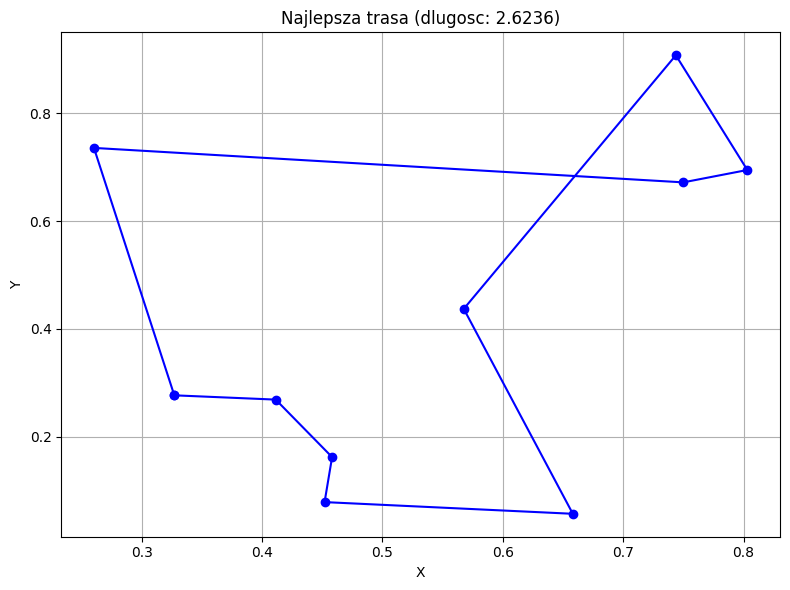

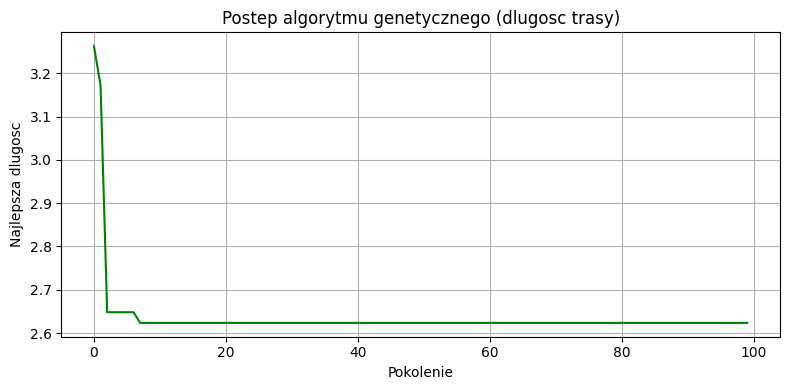

Eksperyment zakonczony. Czas wykonania: 0.7842 s




Eksperyment 2/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


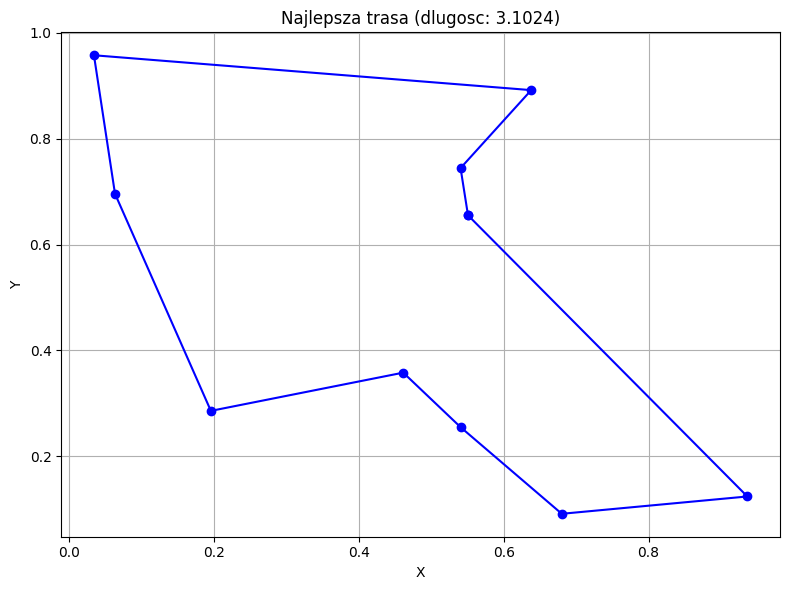

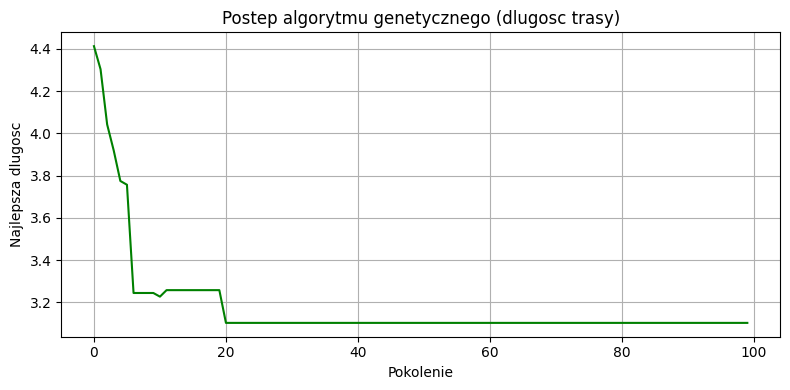

Eksperyment zakonczony. Czas wykonania: 0.7137 s




Eksperyment 3/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


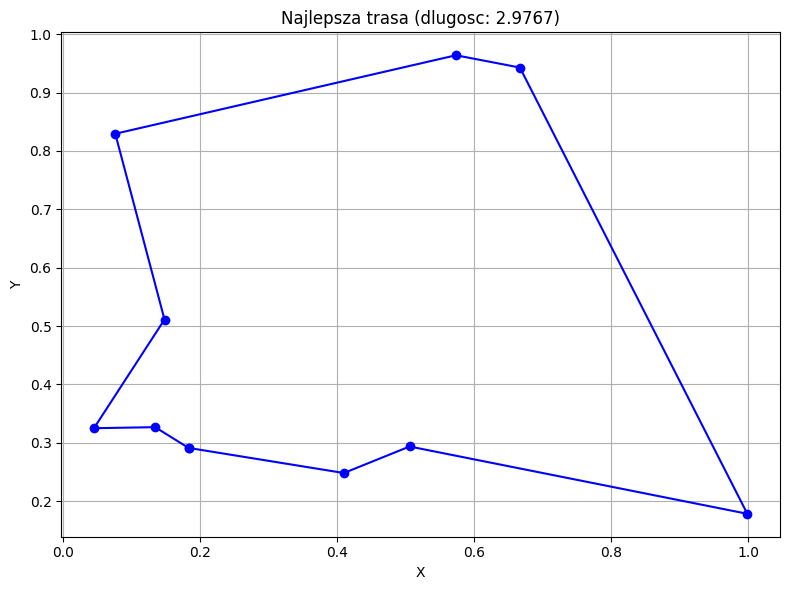

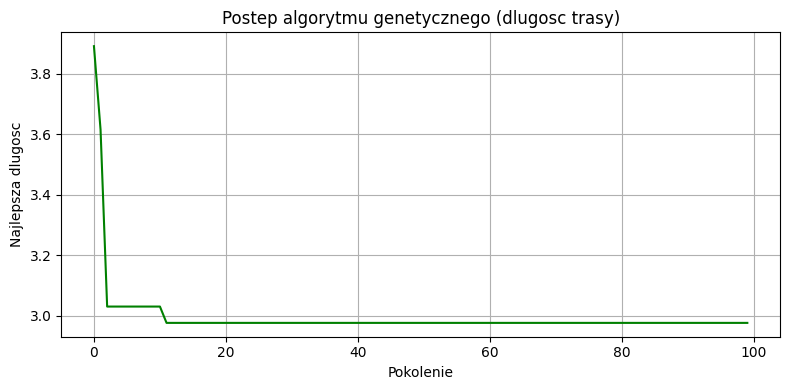

Eksperyment zakonczony. Czas wykonania: 0.8027 s




Eksperyment 4/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


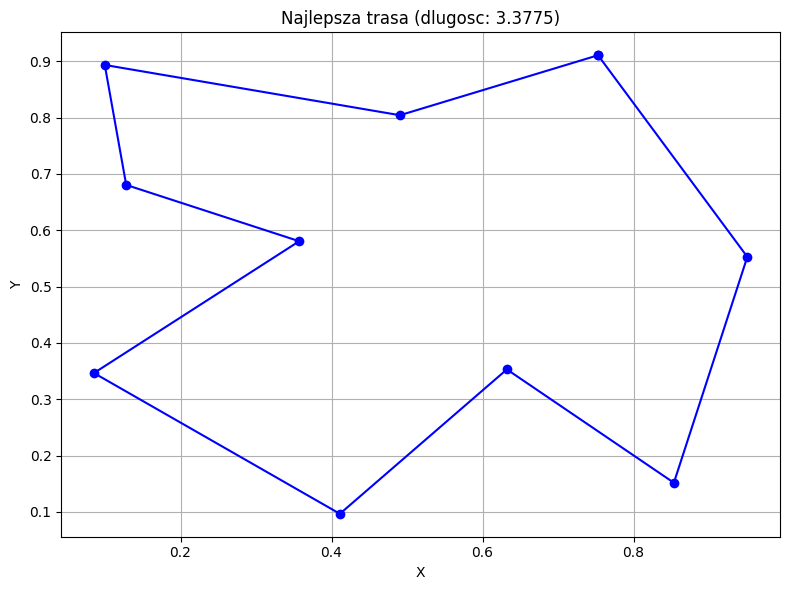

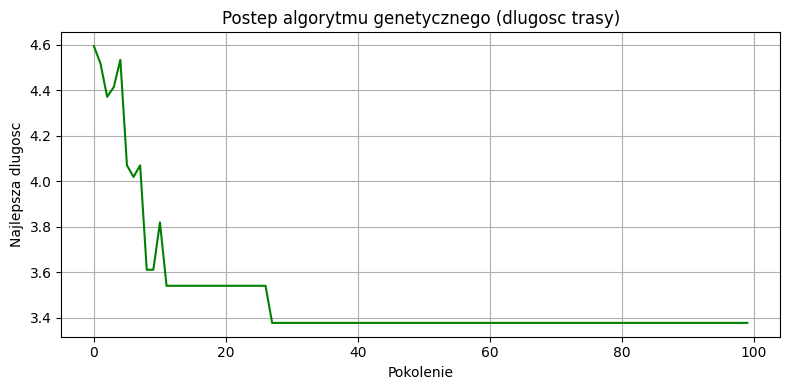

Eksperyment zakonczony. Czas wykonania: 0.5823 s




Eksperyment 5/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


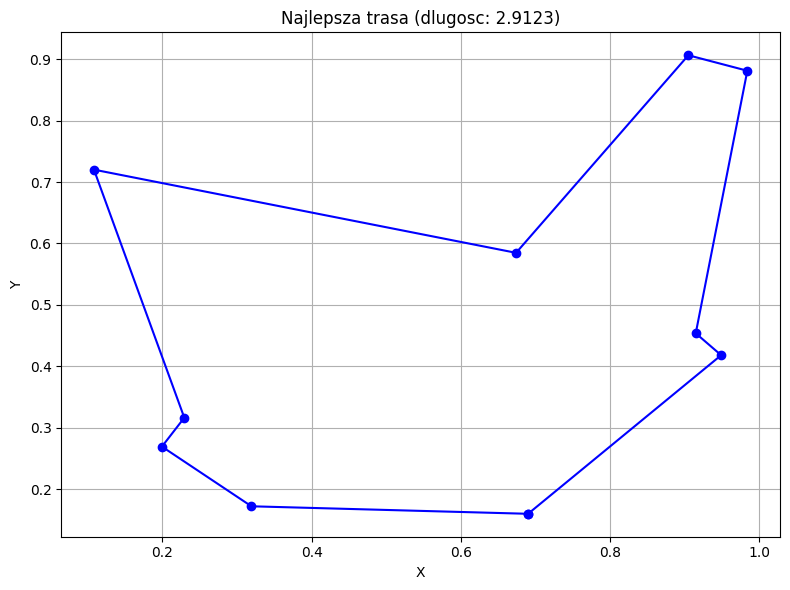

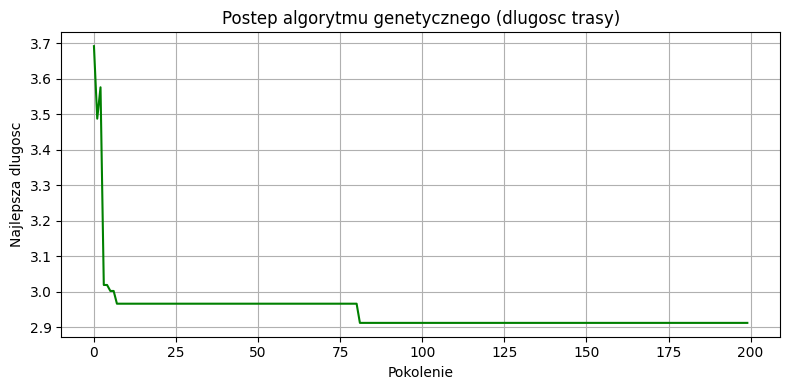

Eksperyment zakonczony. Czas wykonania: 0.8376 s




Eksperyment 6/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


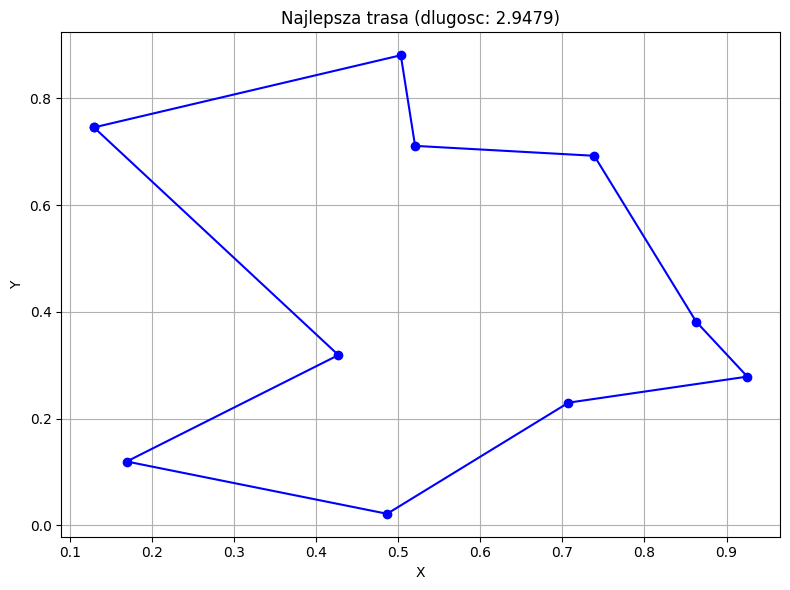

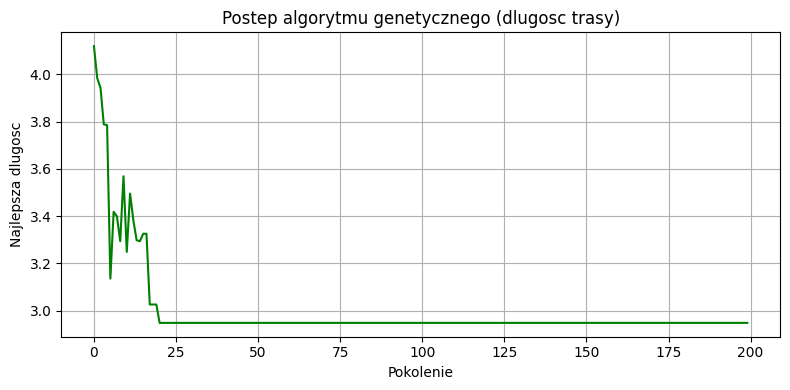

Eksperyment zakonczony. Czas wykonania: 0.7797 s




Eksperyment 7/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


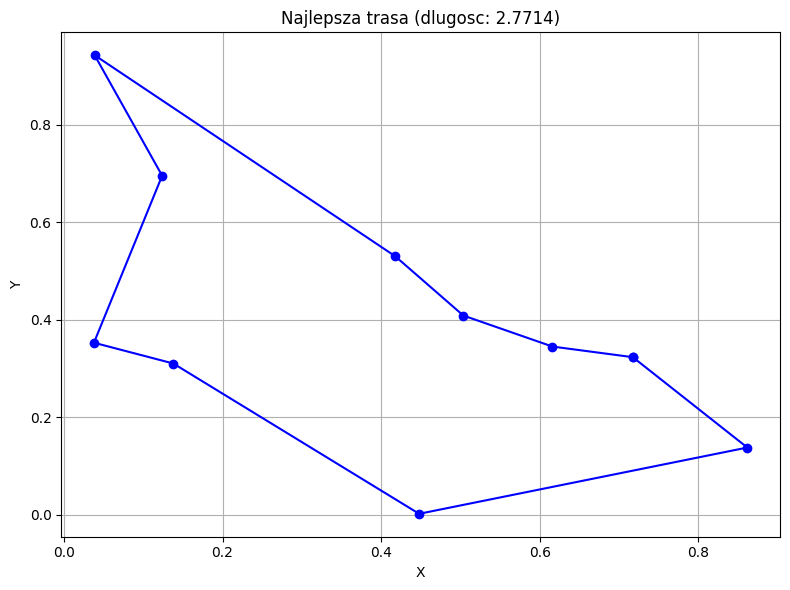

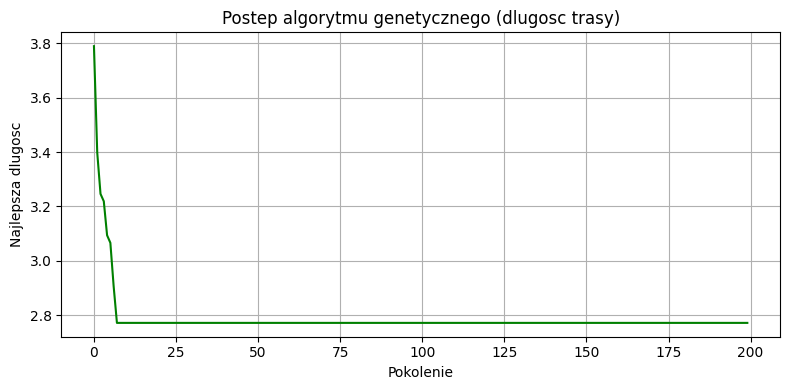

Eksperyment zakonczony. Czas wykonania: 0.9063 s




Eksperyment 8/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


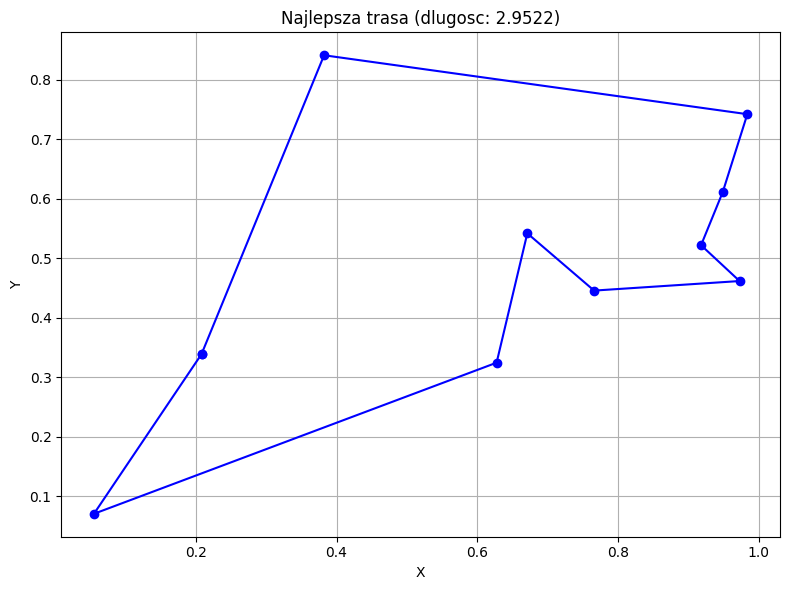

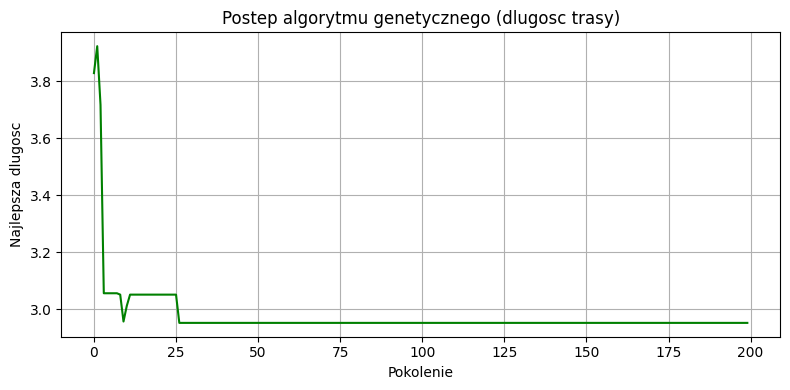

Eksperyment zakonczony. Czas wykonania: 0.9257 s




Eksperyment 9/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


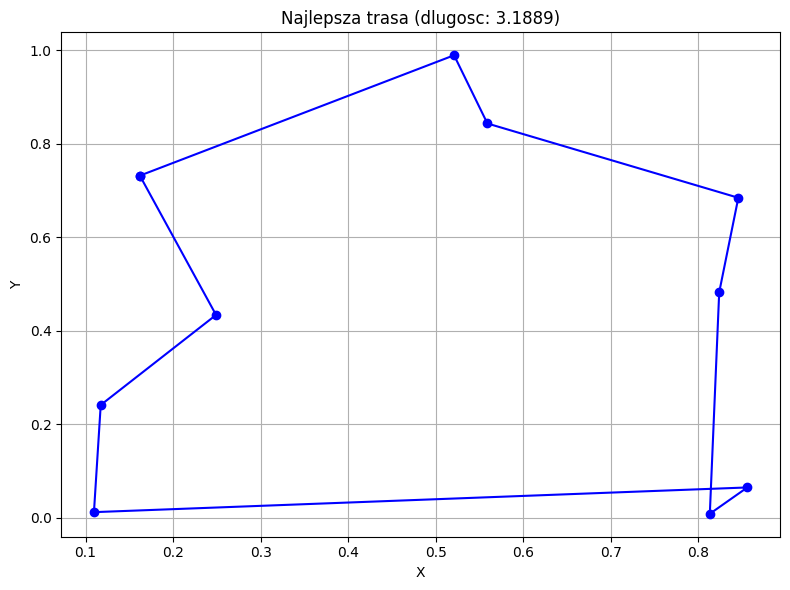

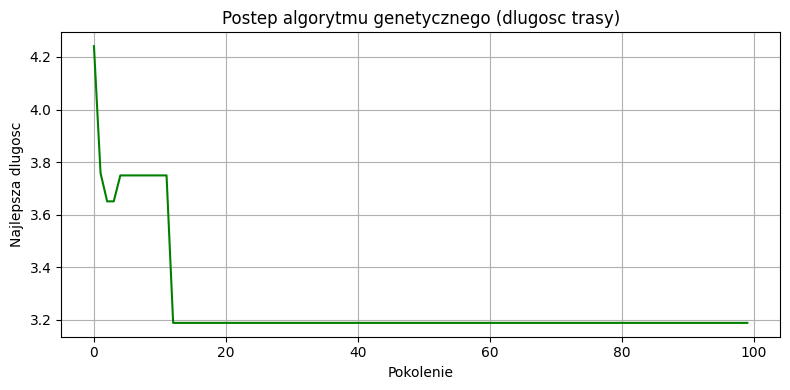

Eksperyment zakonczony. Czas wykonania: 0.8073 s




Eksperyment 10/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


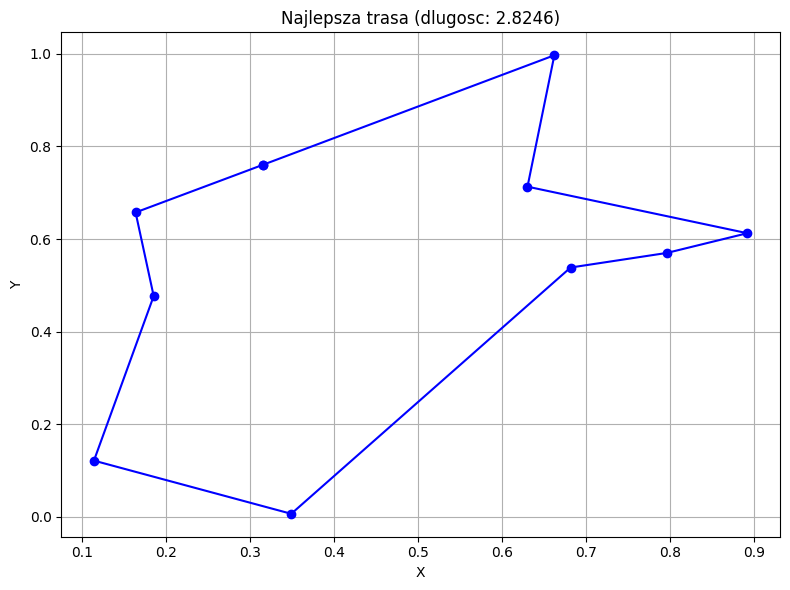

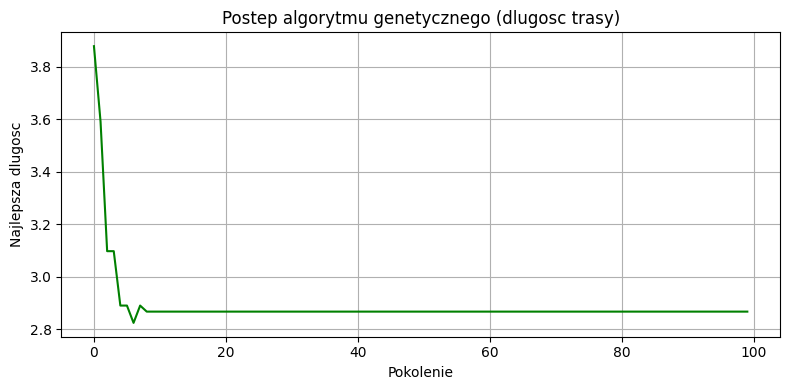

Eksperyment zakonczony. Czas wykonania: 0.8875 s




Eksperyment 11/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


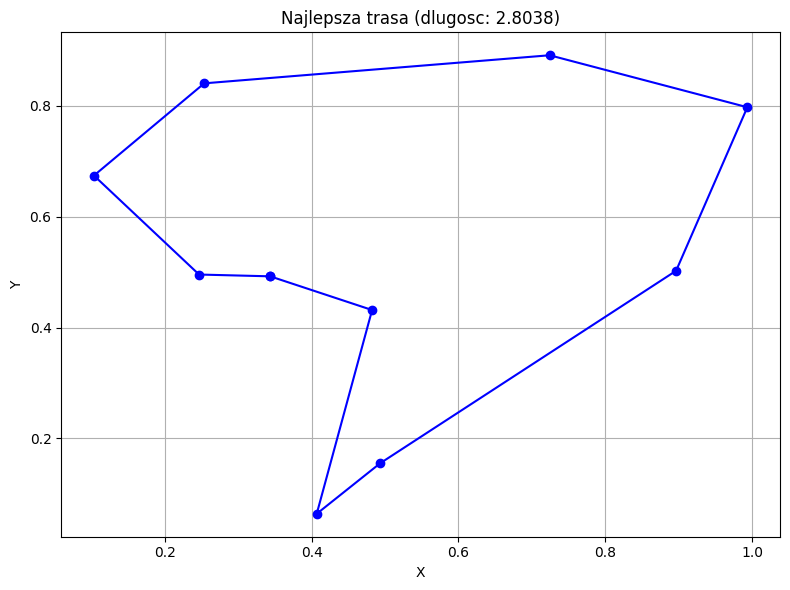

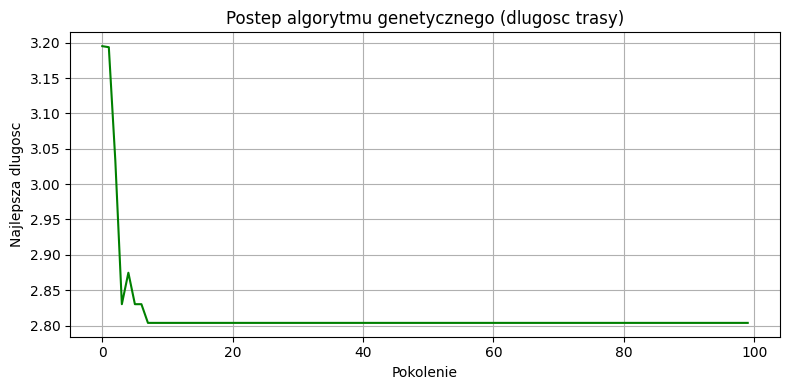

Eksperyment zakonczony. Czas wykonania: 1.0261 s




Eksperyment 12/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


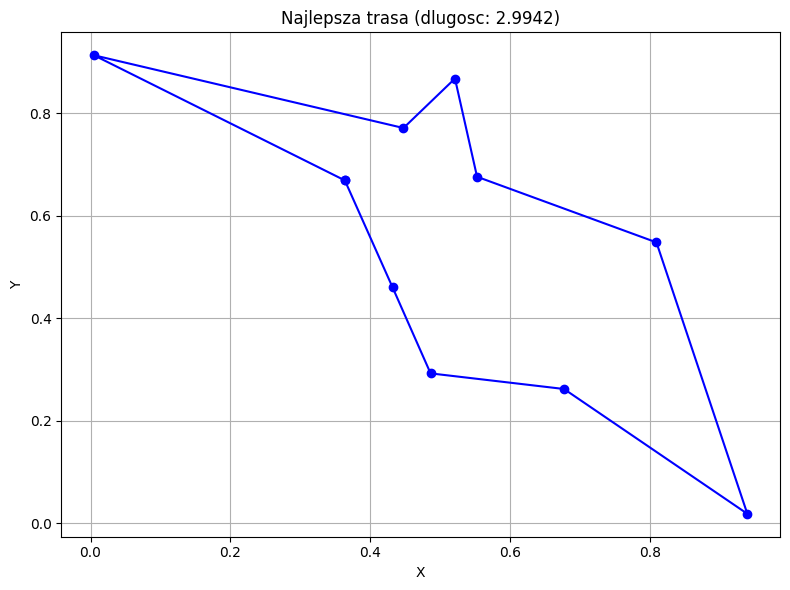

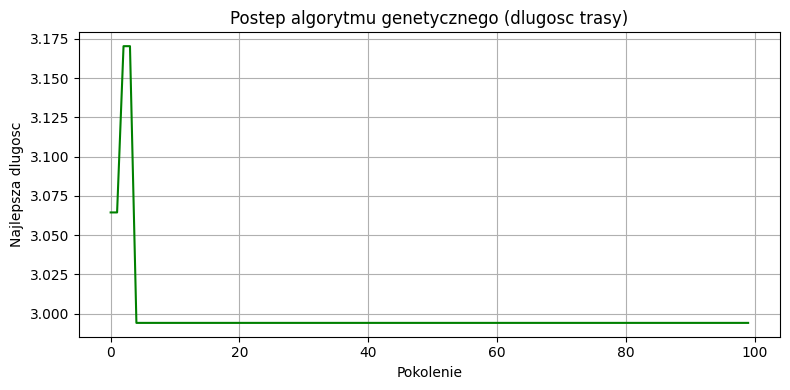

Eksperyment zakonczony. Czas wykonania: 0.9302 s




Eksperyment 13/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


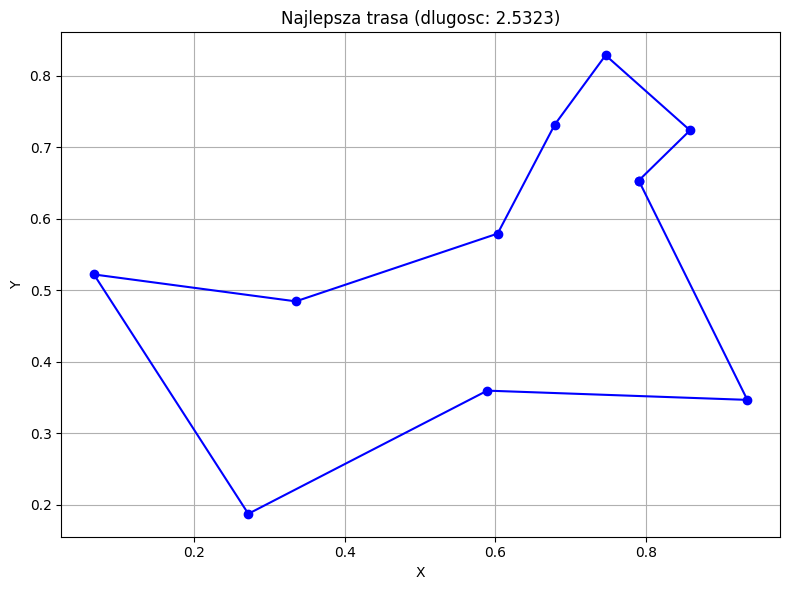

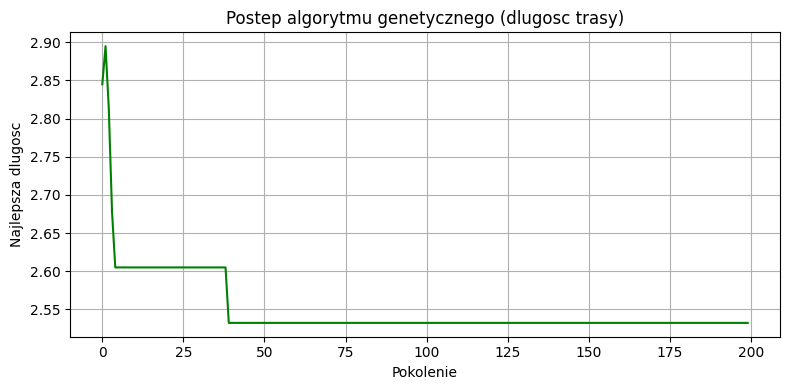

Eksperyment zakonczony. Czas wykonania: 1.3787 s




Eksperyment 14/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


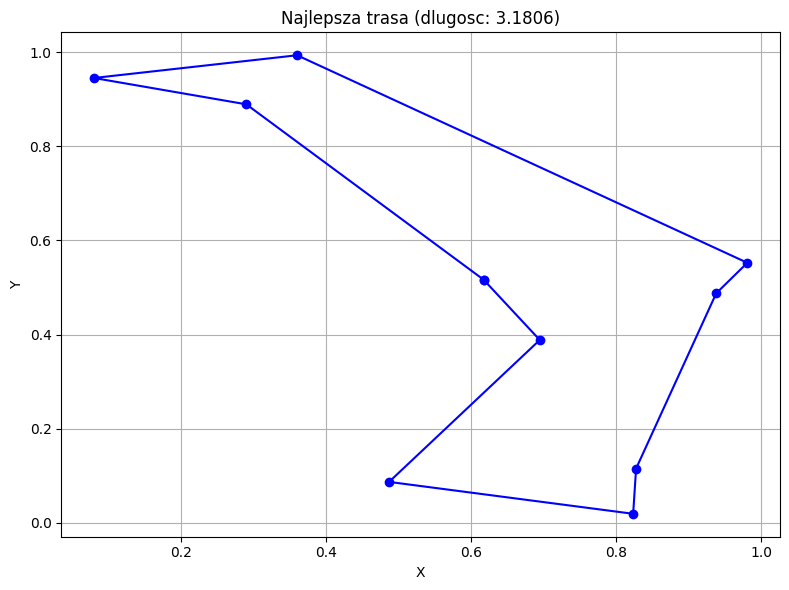

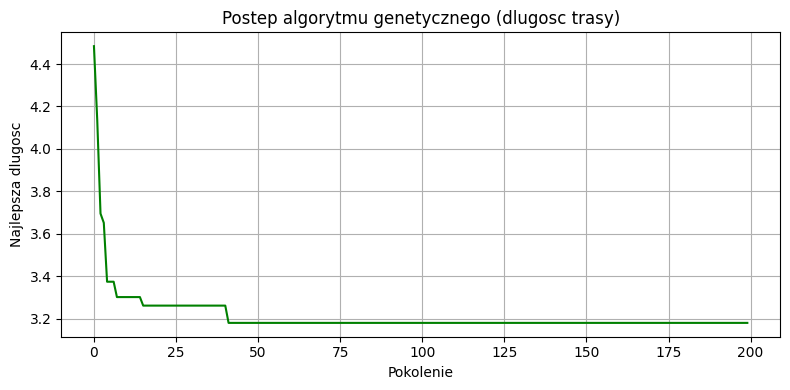

Eksperyment zakonczony. Czas wykonania: 1.5807 s




Eksperyment 15/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


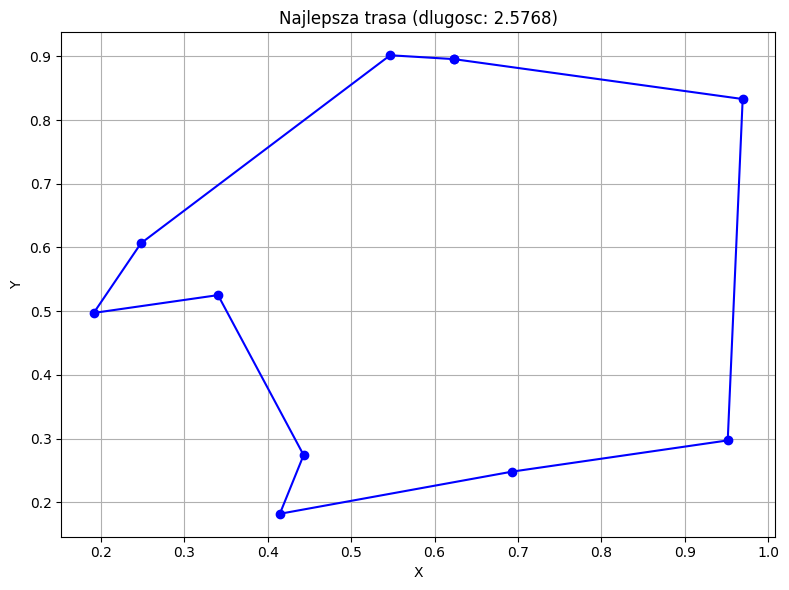

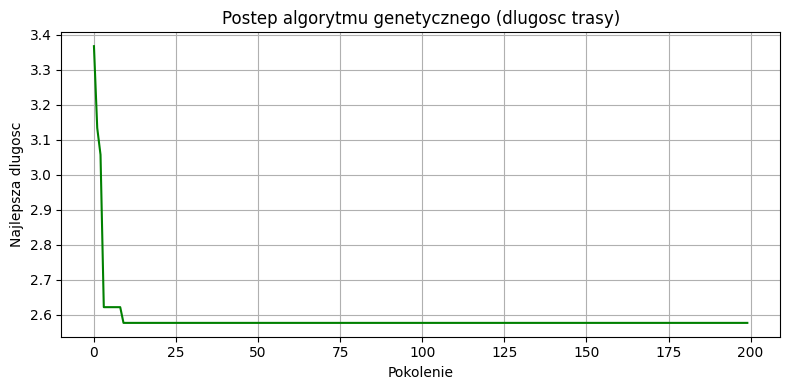

Eksperyment zakonczony. Czas wykonania: 2.0411 s




Eksperyment 16/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


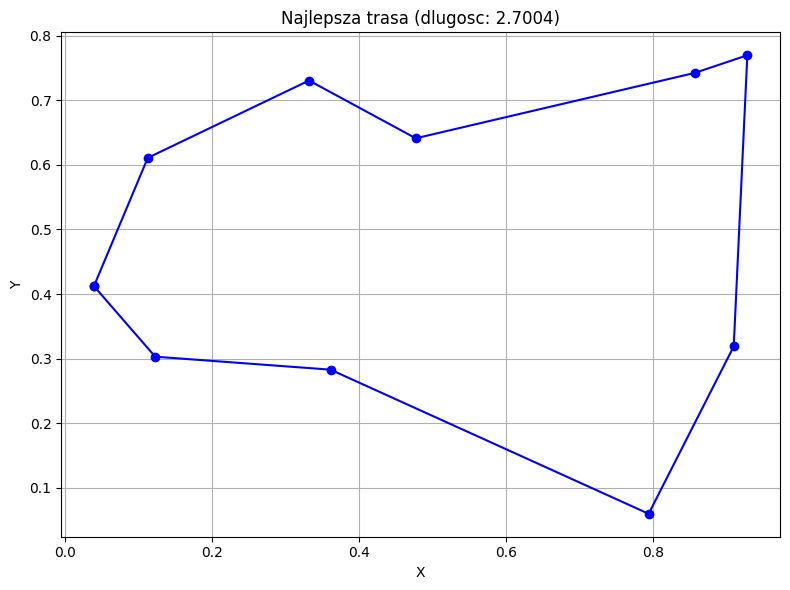

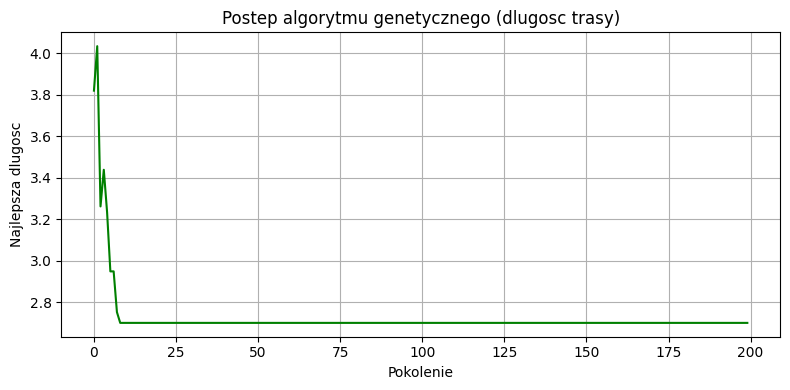

Eksperyment zakonczony. Czas wykonania: 1.7952 s




Eksperyment 17/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


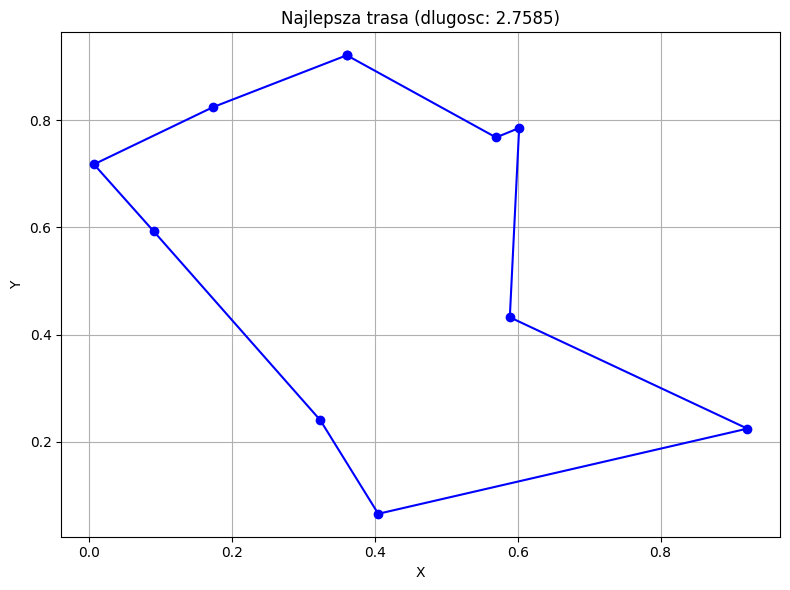

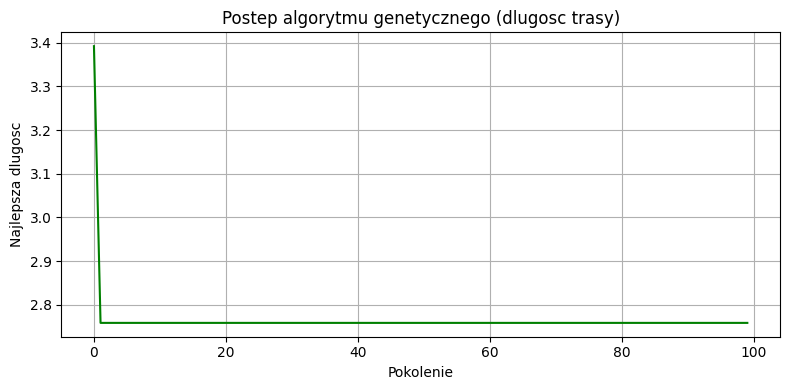

Eksperyment zakonczony. Czas wykonania: 7.9676 s




Eksperyment 18/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


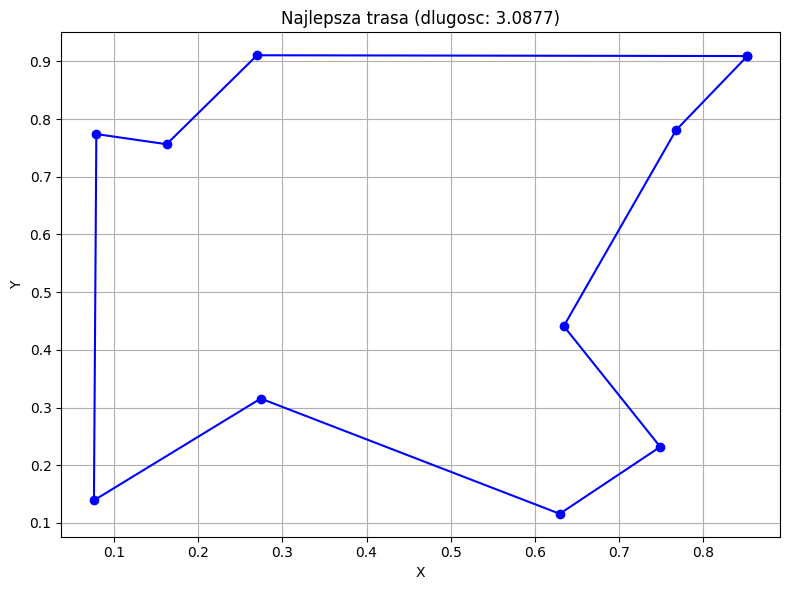

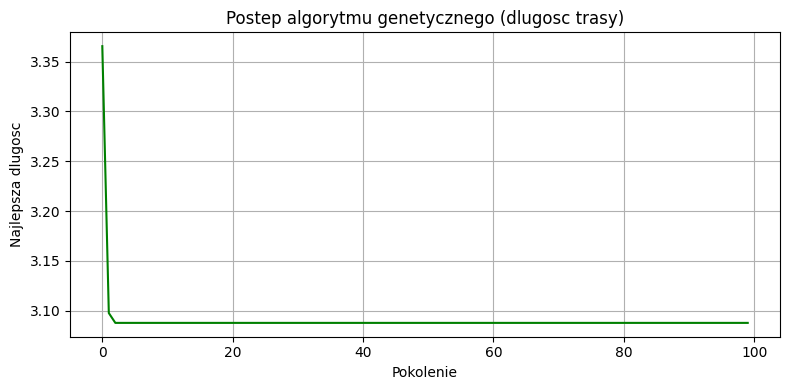

Eksperyment zakonczony. Czas wykonania: 6.2831 s




Eksperyment 19/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


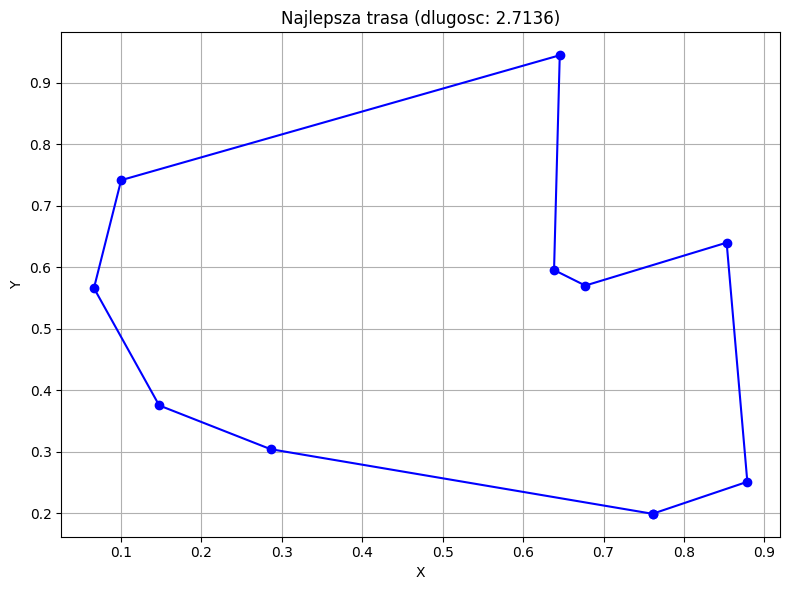

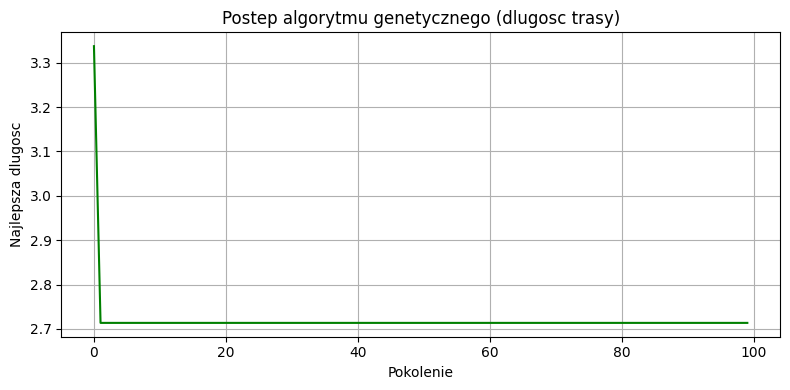

Eksperyment zakonczony. Czas wykonania: 5.2005 s




Eksperyment 20/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


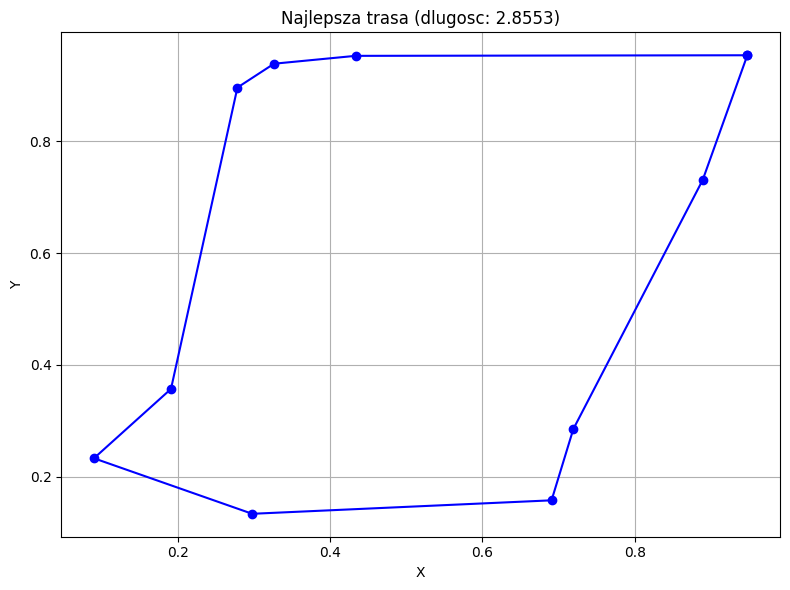

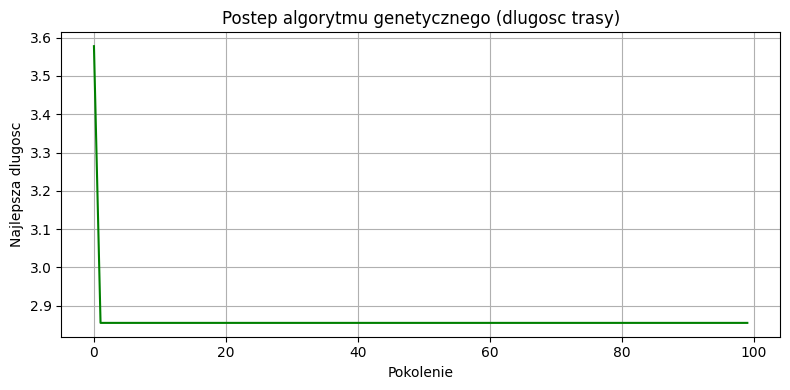

Eksperyment zakonczony. Czas wykonania: 5.6213 s




Eksperyment 21/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


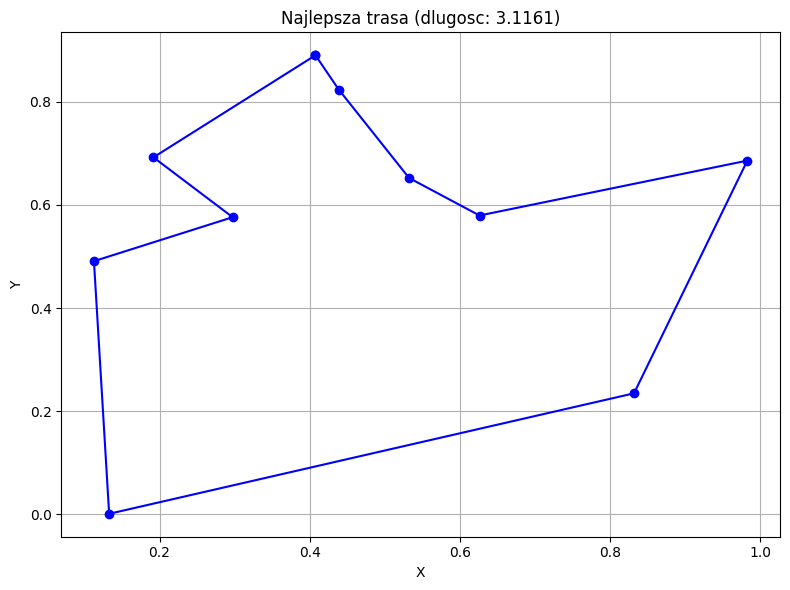

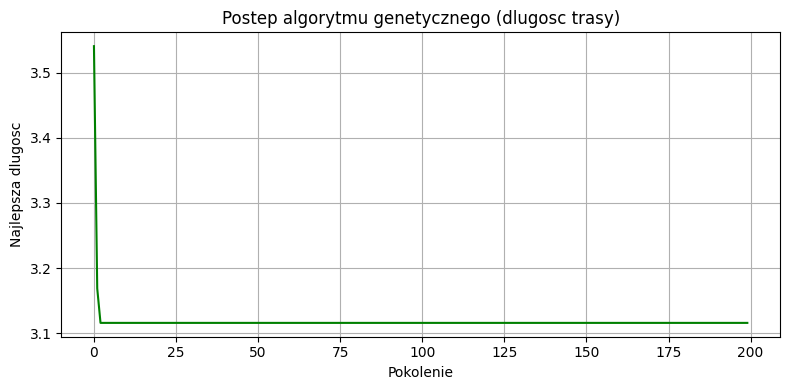

Eksperyment zakonczony. Czas wykonania: 10.9879 s




Eksperyment 22/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


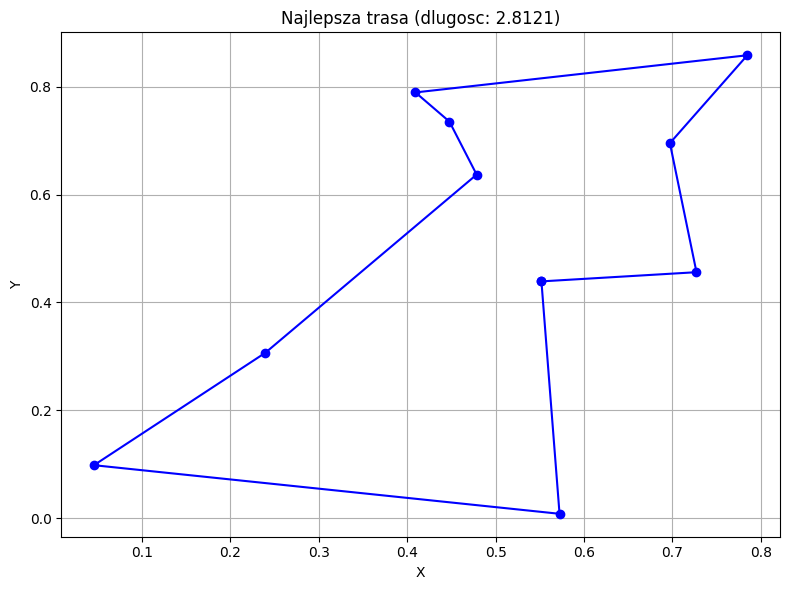

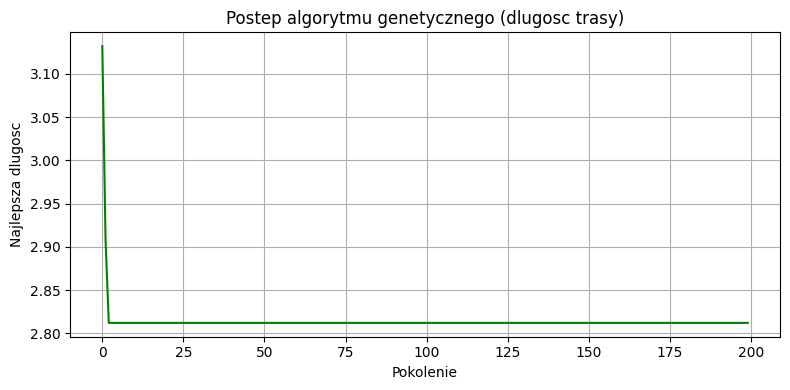

Eksperyment zakonczony. Czas wykonania: 11.5808 s




Eksperyment 23/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


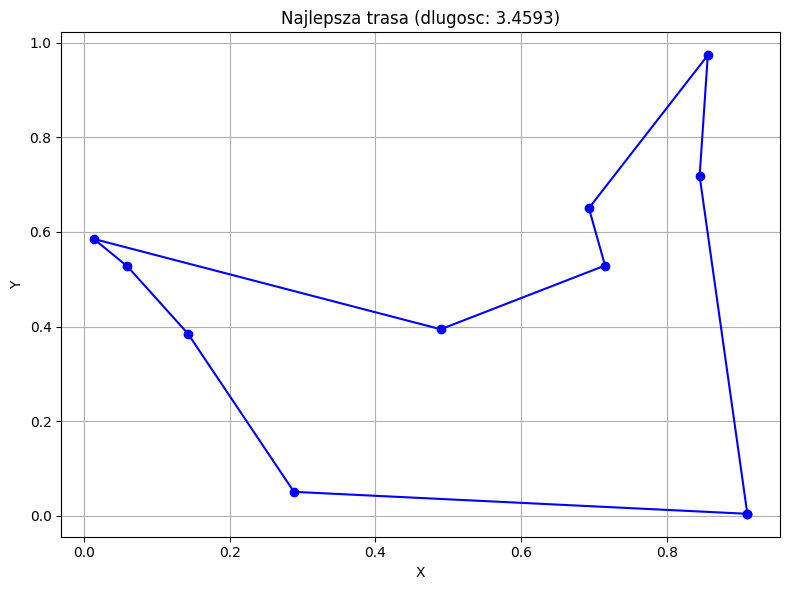

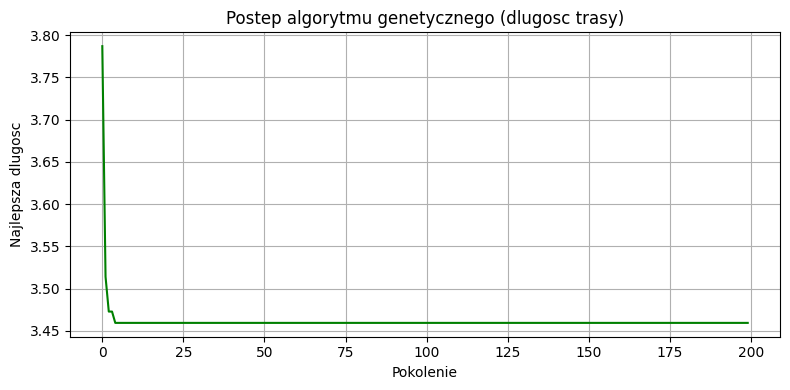

Eksperyment zakonczony. Czas wykonania: 10.0331 s




Eksperyment 24/72:
Start eksperymentu:
- Liczba miast      : 10
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


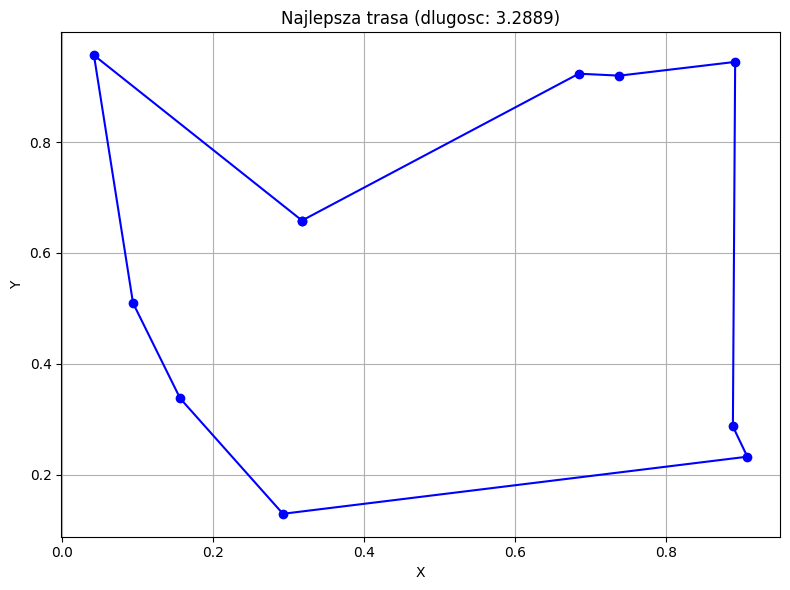

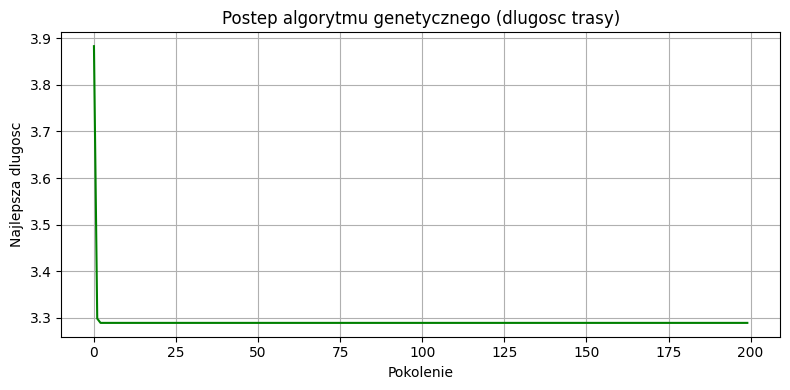

Eksperyment zakonczony. Czas wykonania: 9.6287 s




Eksperyment 25/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


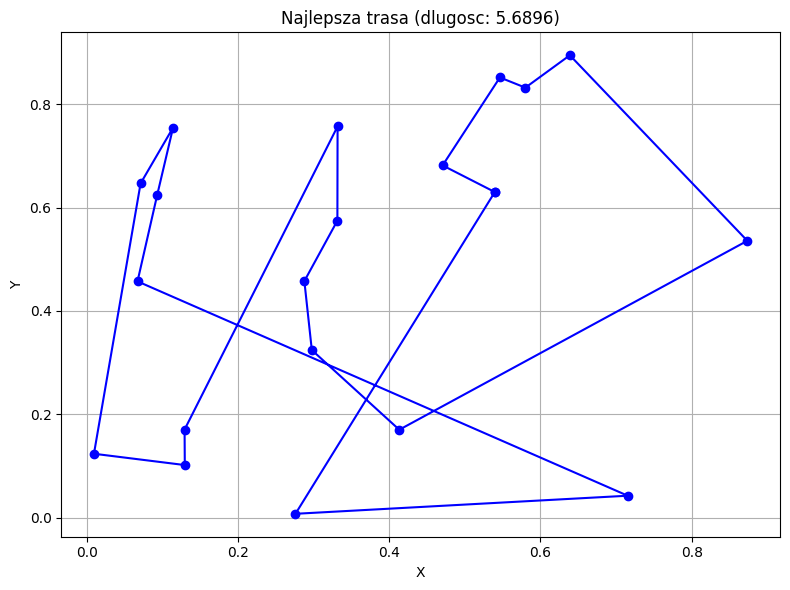

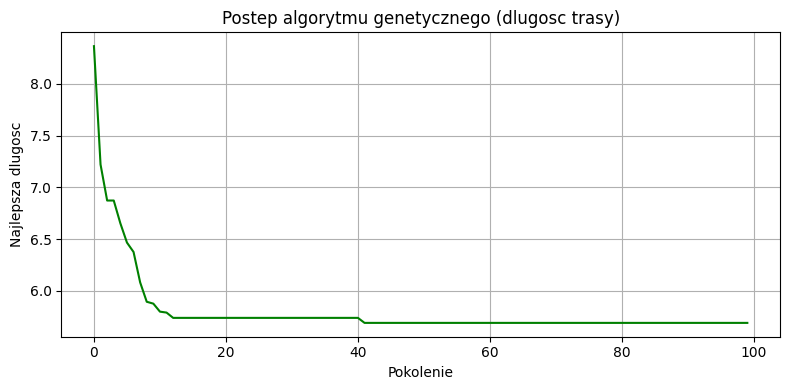

Eksperyment zakonczony. Czas wykonania: 0.6981 s




Eksperyment 26/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


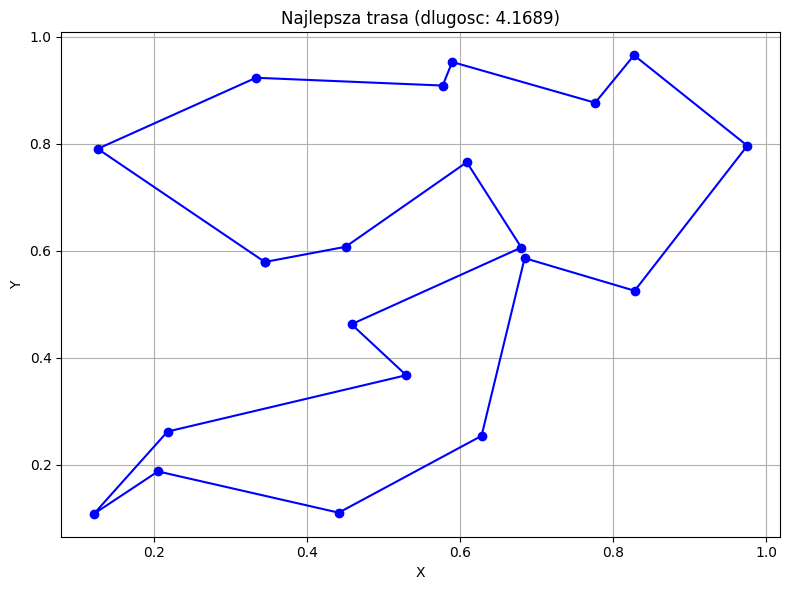

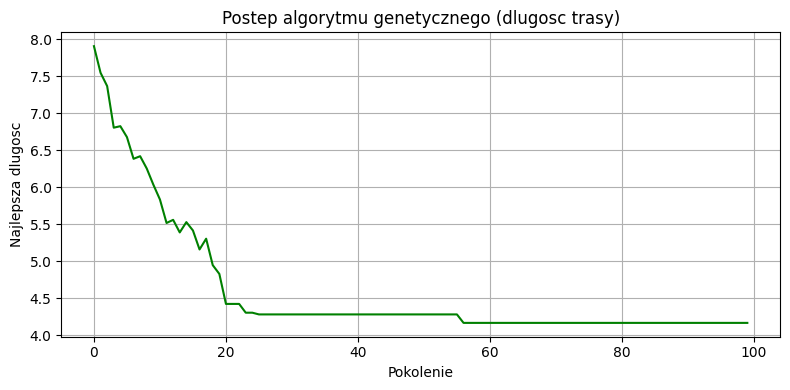

Eksperyment zakonczony. Czas wykonania: 0.9413 s




Eksperyment 27/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


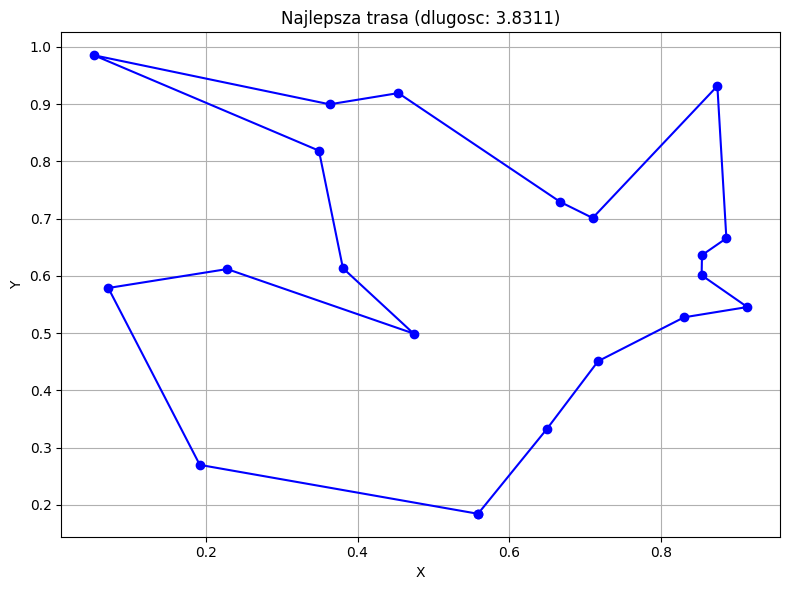

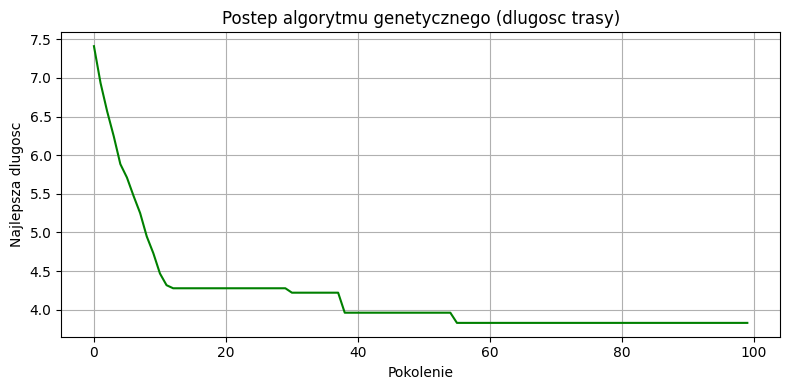

Eksperyment zakonczony. Czas wykonania: 0.8283 s




Eksperyment 28/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


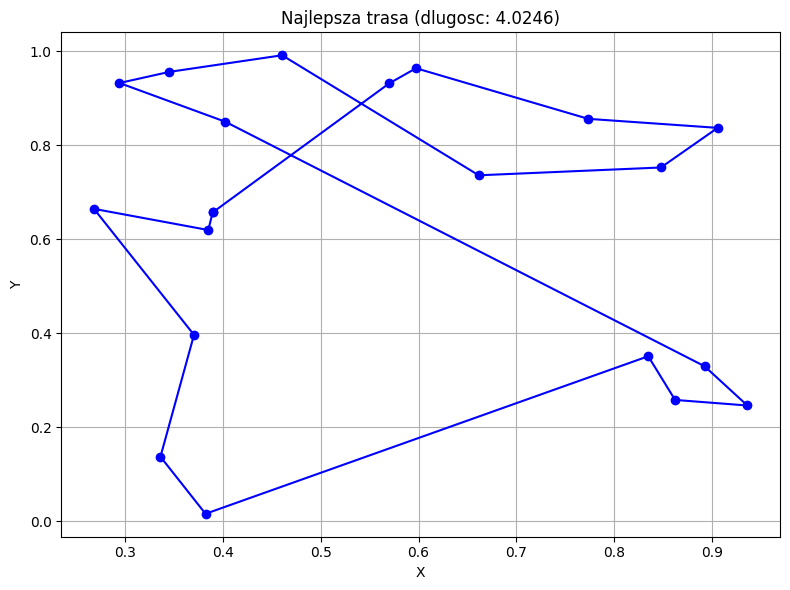

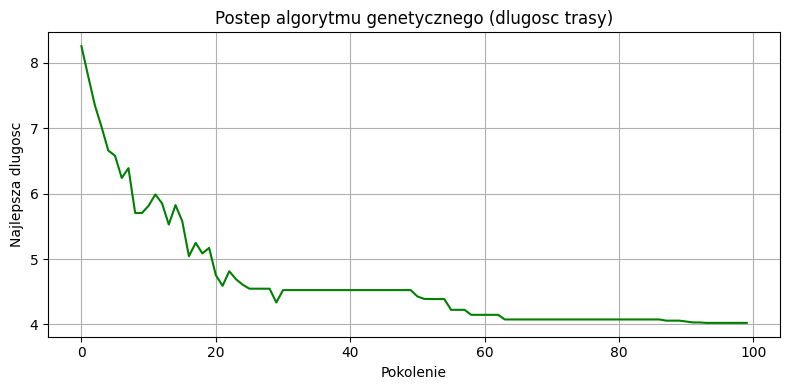

Eksperyment zakonczony. Czas wykonania: 0.7524 s




Eksperyment 29/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


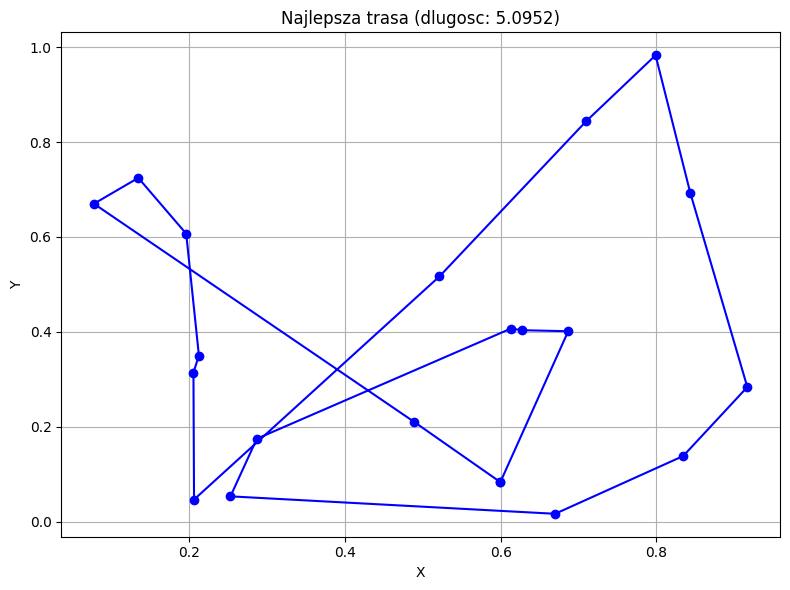

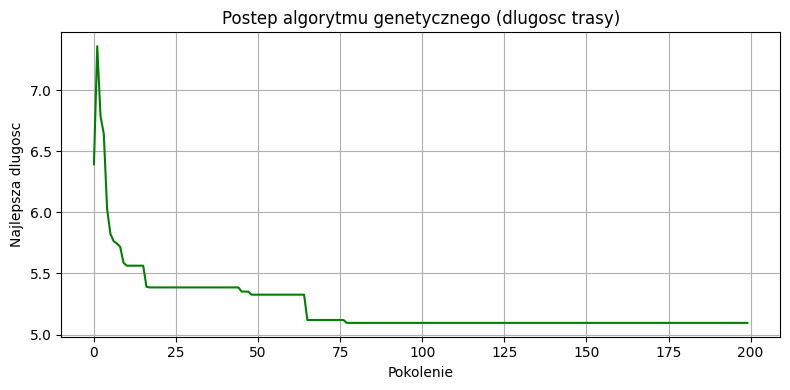

Eksperyment zakonczony. Czas wykonania: 1.3538 s




Eksperyment 30/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


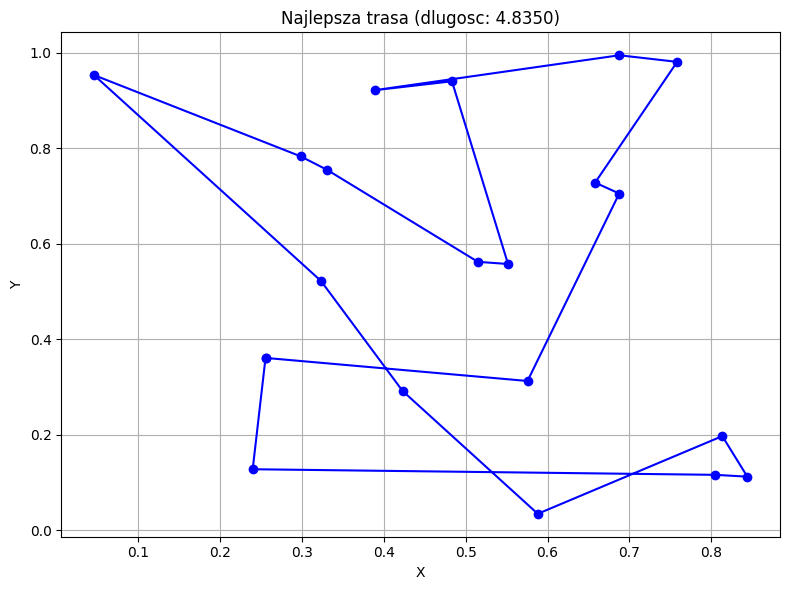

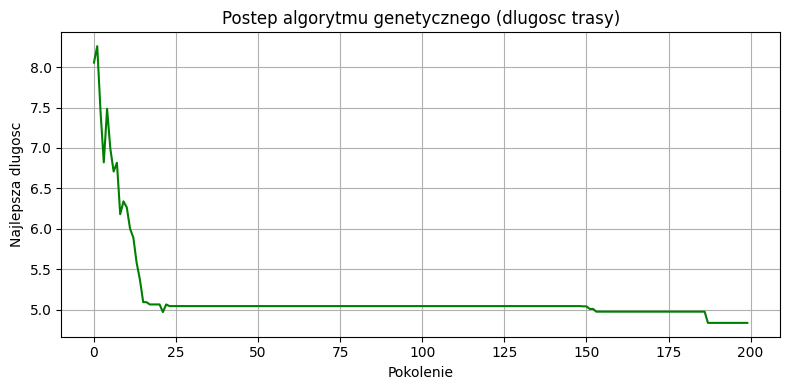

Eksperyment zakonczony. Czas wykonania: 1.4501 s




Eksperyment 31/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


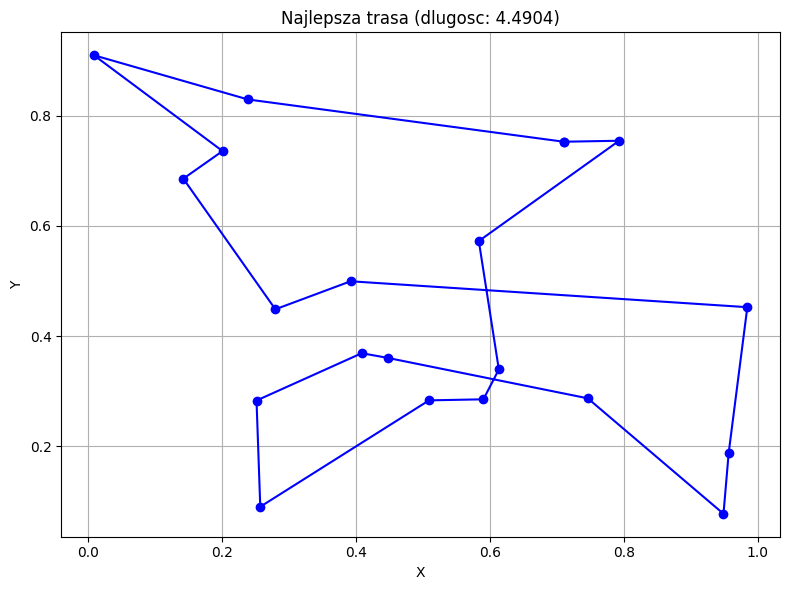

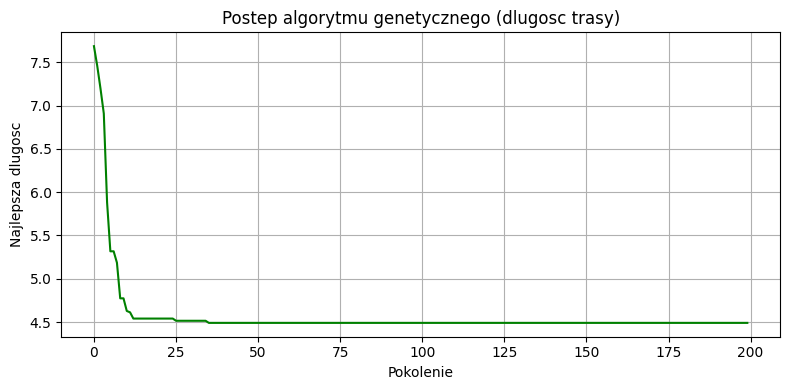

Eksperyment zakonczony. Czas wykonania: 1.4672 s




Eksperyment 32/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


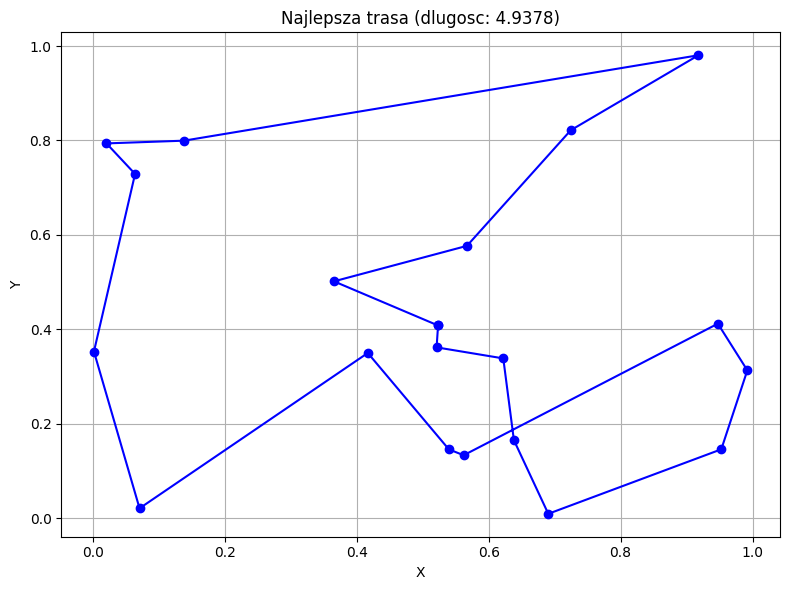

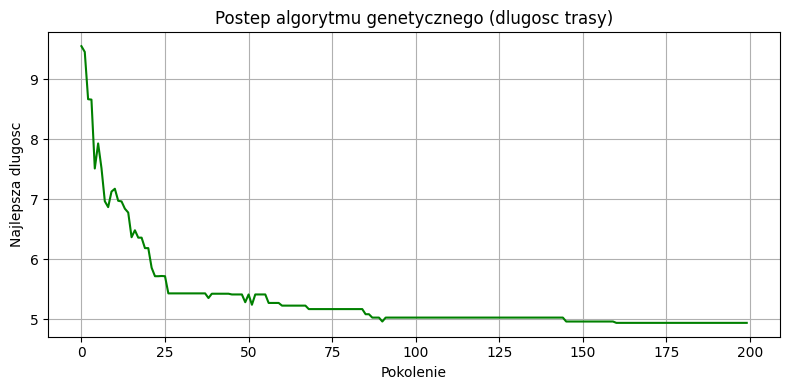

Eksperyment zakonczony. Czas wykonania: 1.3446 s




Eksperyment 33/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


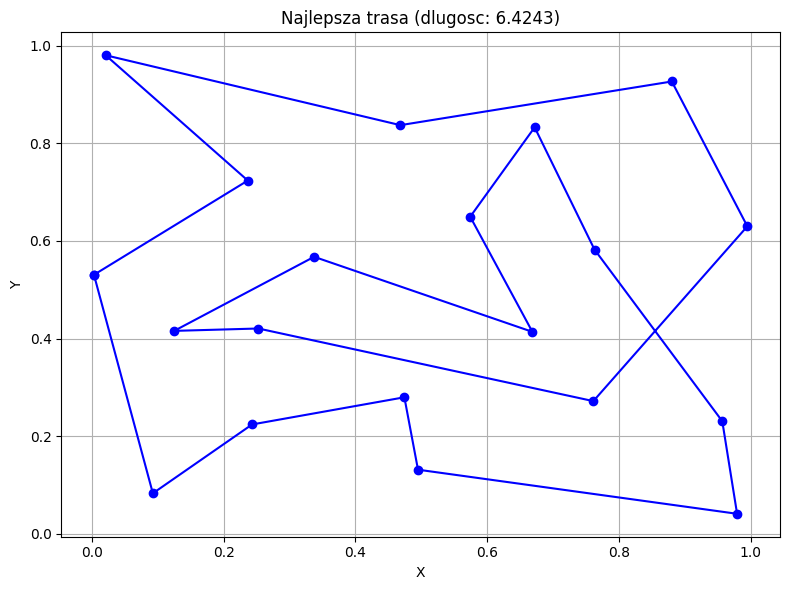

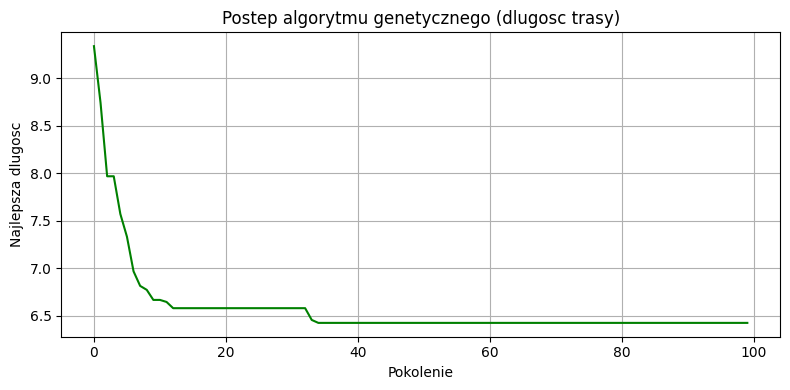

Eksperyment zakonczony. Czas wykonania: 1.1934 s




Eksperyment 34/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


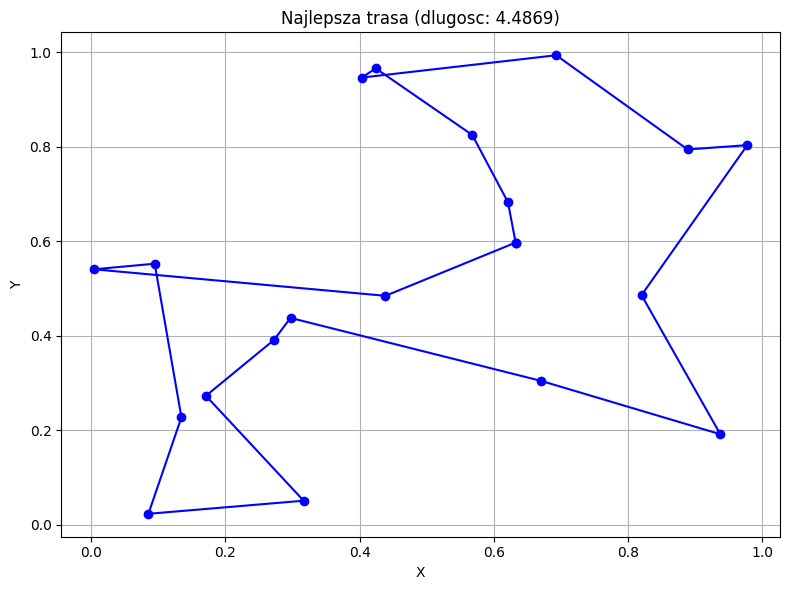

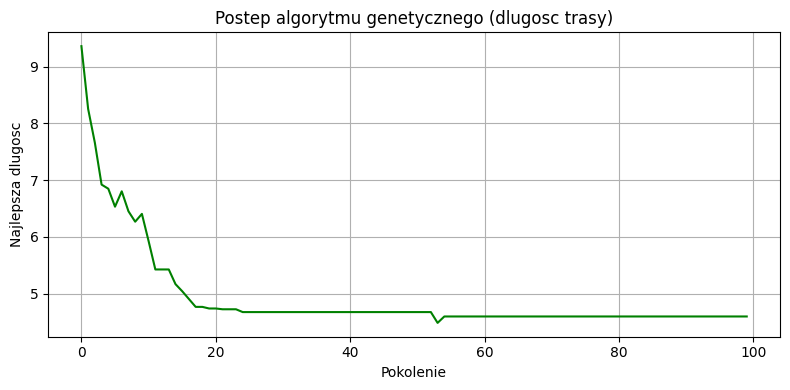

Eksperyment zakonczony. Czas wykonania: 1.2101 s




Eksperyment 35/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


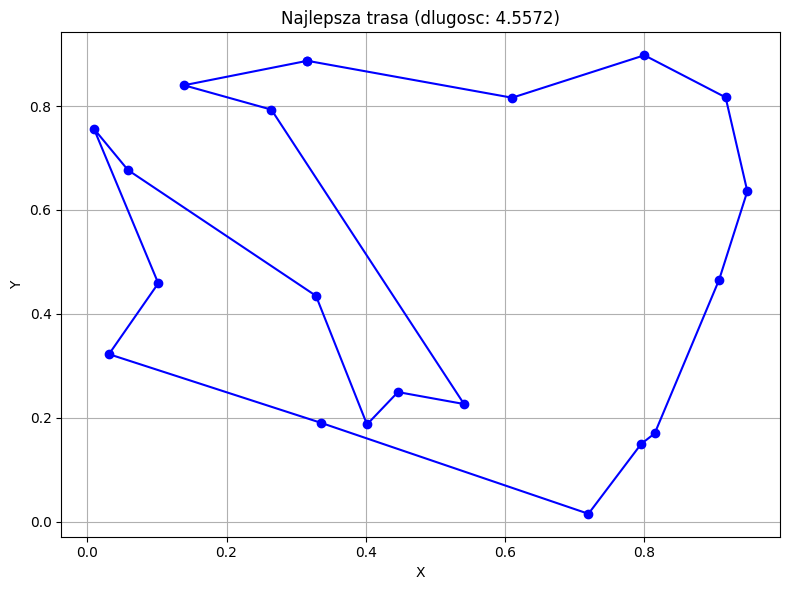

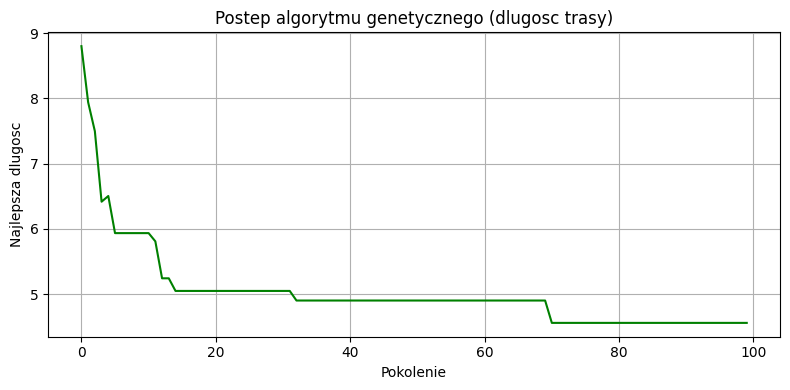

Eksperyment zakonczony. Czas wykonania: 1.1981 s




Eksperyment 36/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


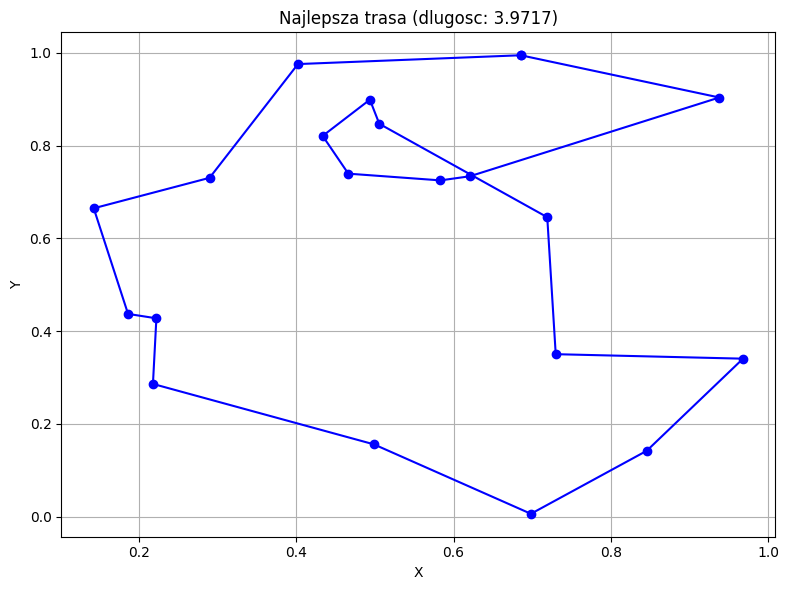

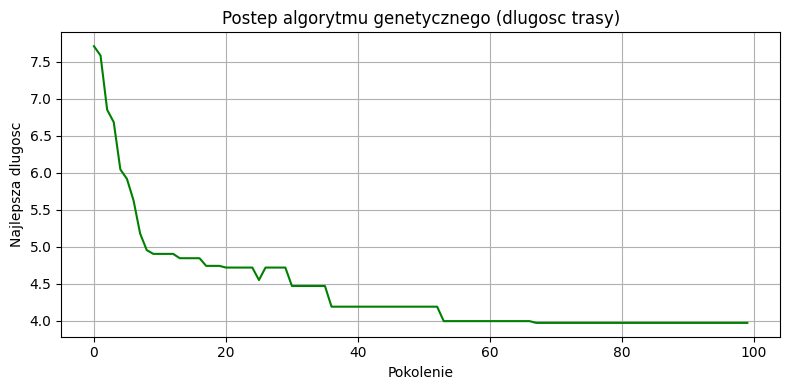

Eksperyment zakonczony. Czas wykonania: 1.4471 s




Eksperyment 37/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


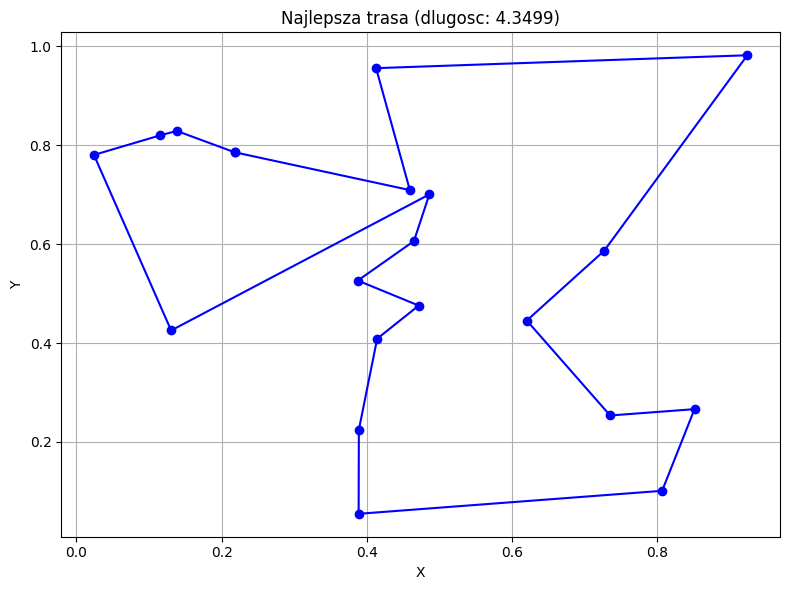

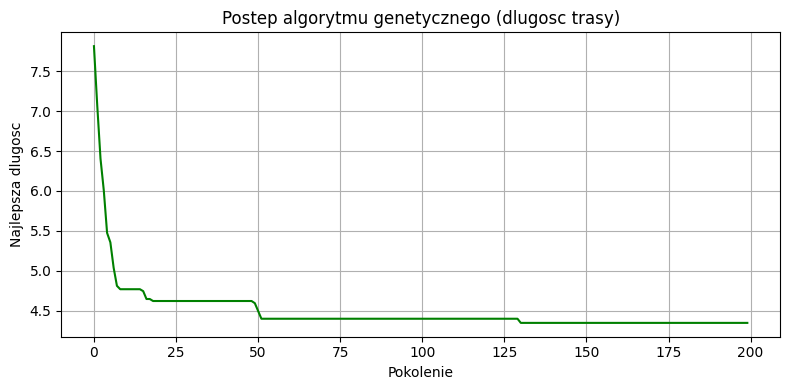

Eksperyment zakonczony. Czas wykonania: 2.1555 s




Eksperyment 38/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


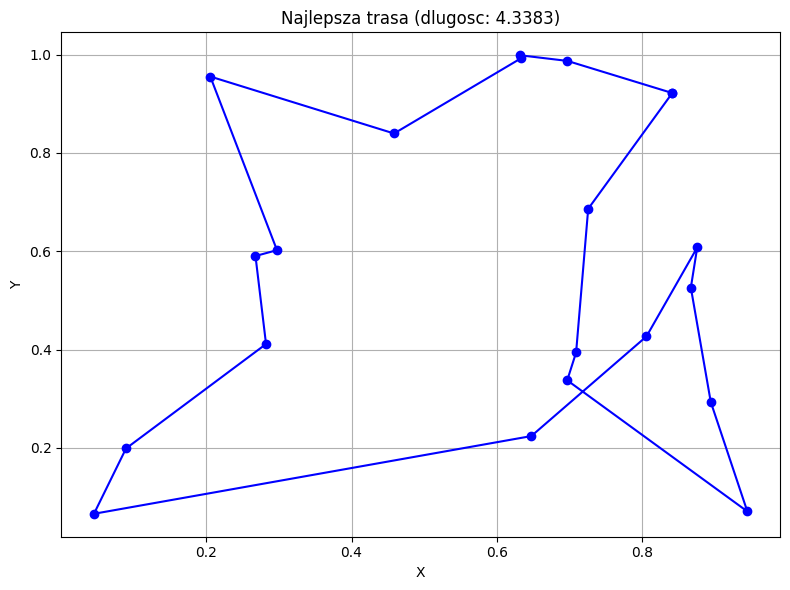

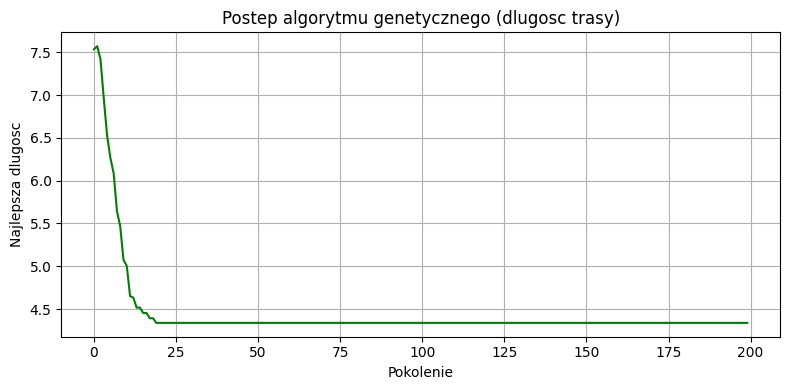

Eksperyment zakonczony. Czas wykonania: 2.0663 s




Eksperyment 39/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


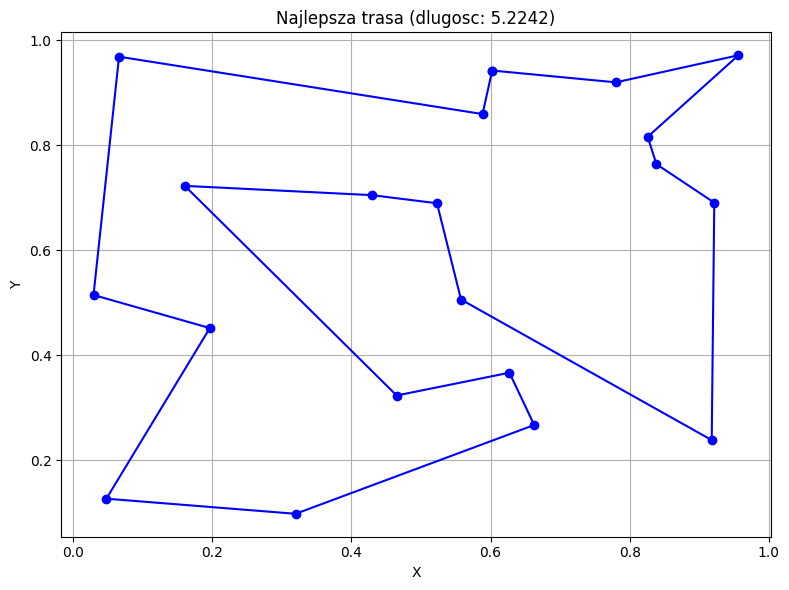

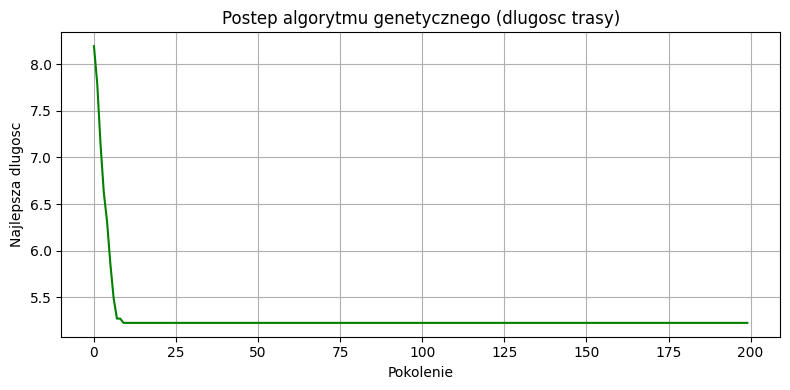

Eksperyment zakonczony. Czas wykonania: 2.1258 s




Eksperyment 40/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


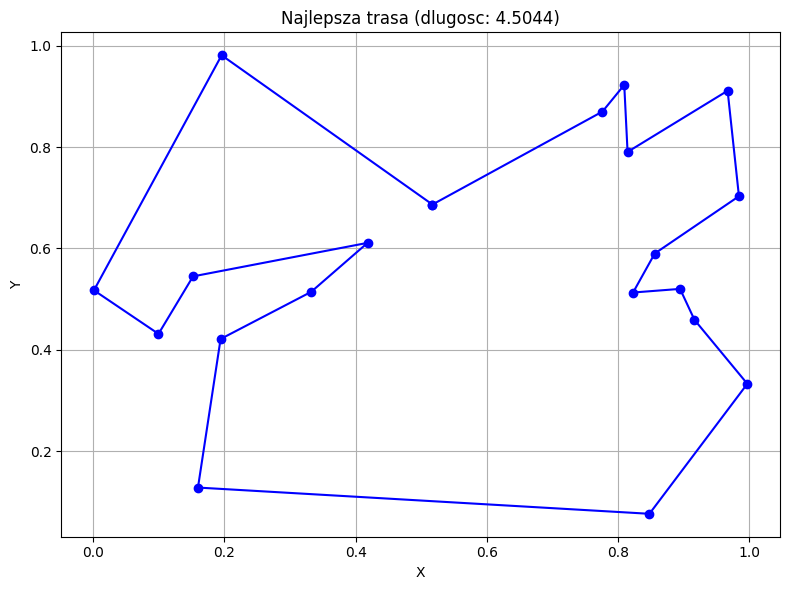

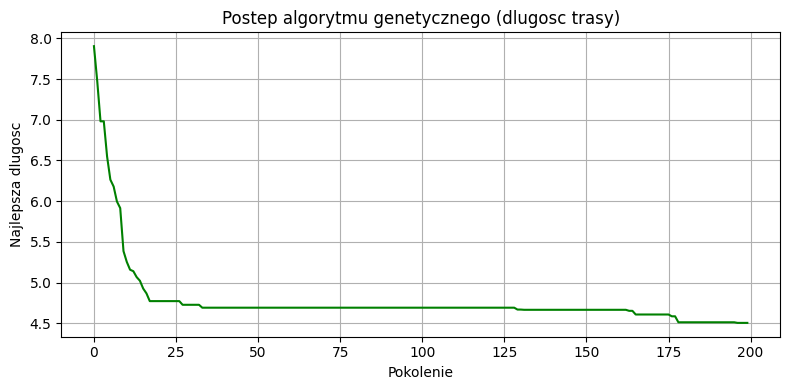

Eksperyment zakonczony. Czas wykonania: 2.24 s




Eksperyment 41/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


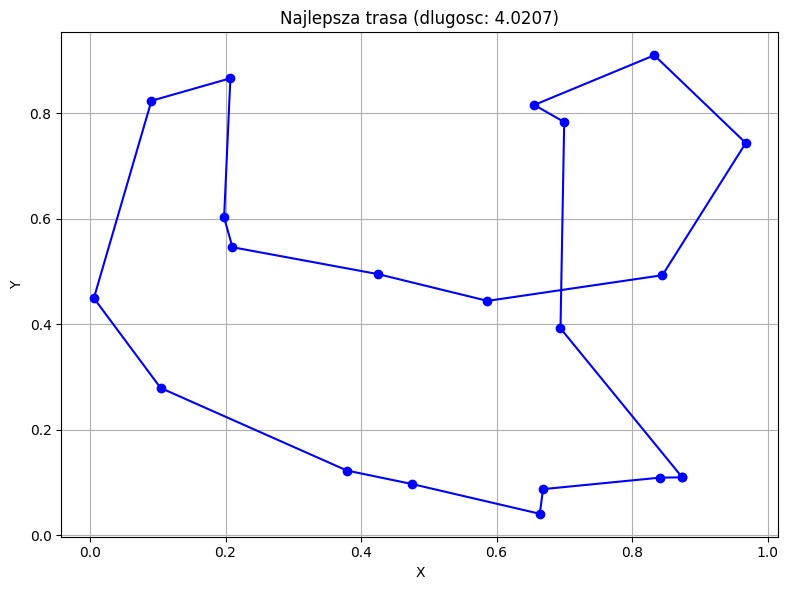

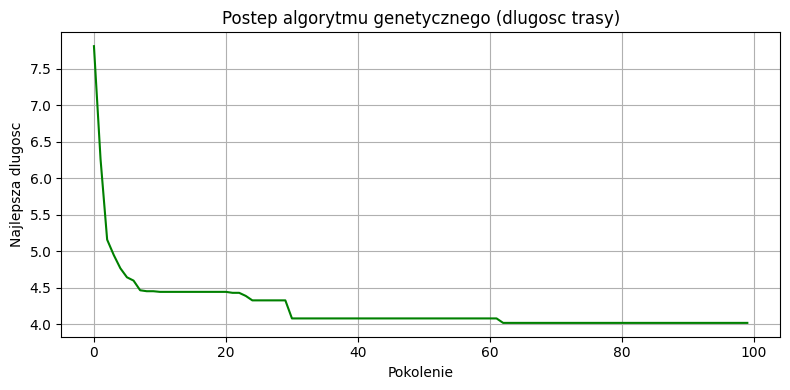

Eksperyment zakonczony. Czas wykonania: 9.6249 s




Eksperyment 42/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


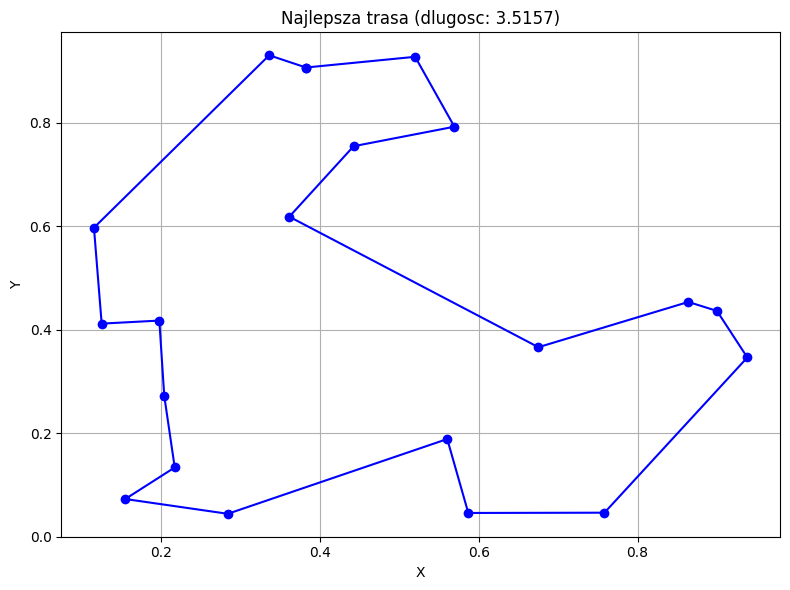

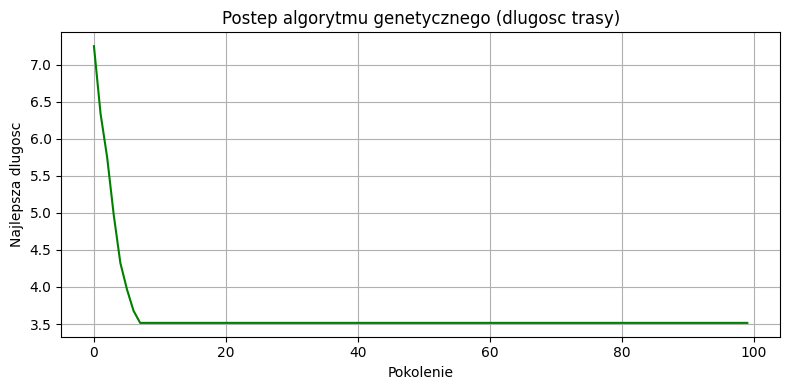

Eksperyment zakonczony. Czas wykonania: 10.7842 s




Eksperyment 43/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


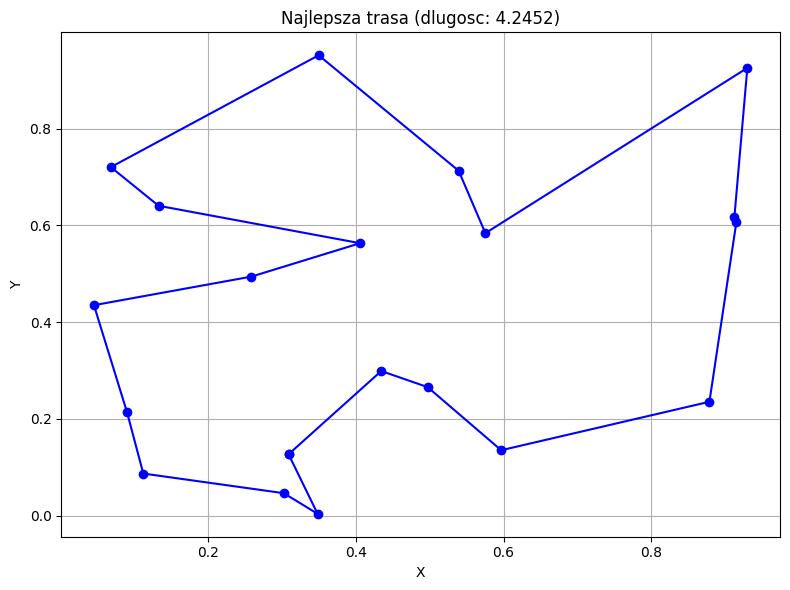

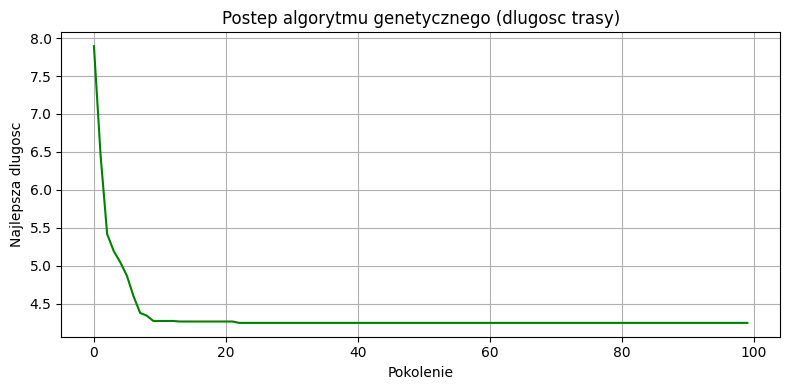

Eksperyment zakonczony. Czas wykonania: 9.8313 s




Eksperyment 44/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


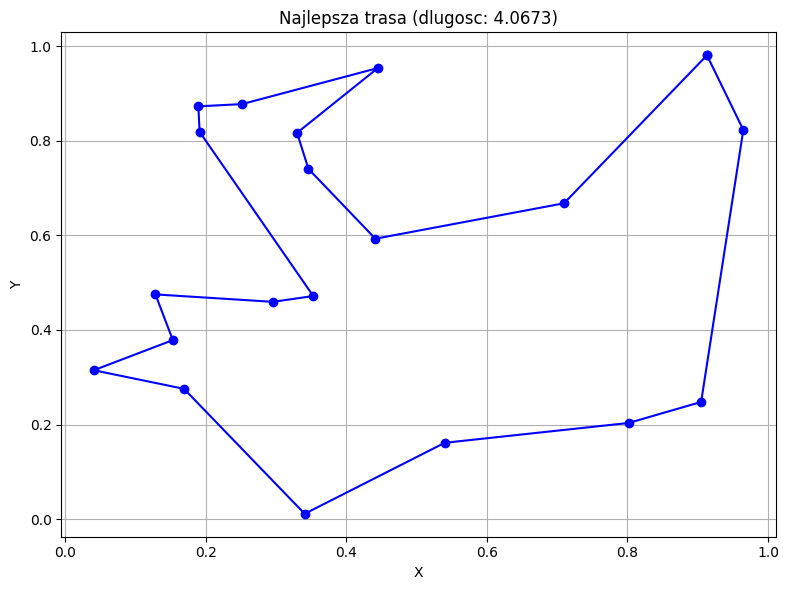

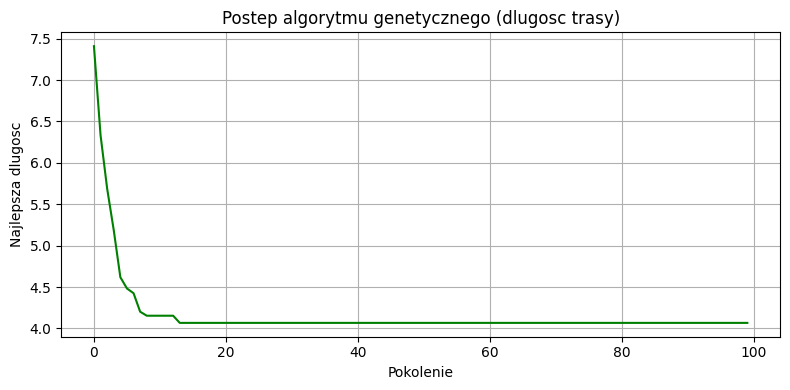

Eksperyment zakonczony. Czas wykonania: 9.6615 s




Eksperyment 45/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


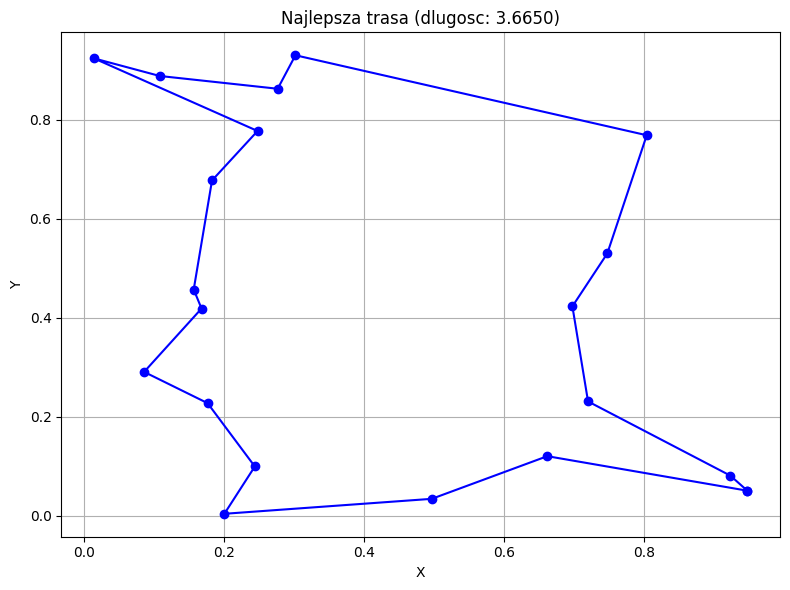

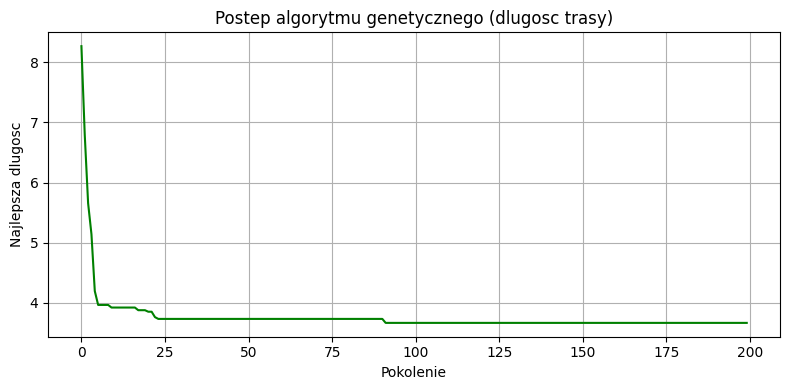

Eksperyment zakonczony. Czas wykonania: 20.5972 s




Eksperyment 46/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


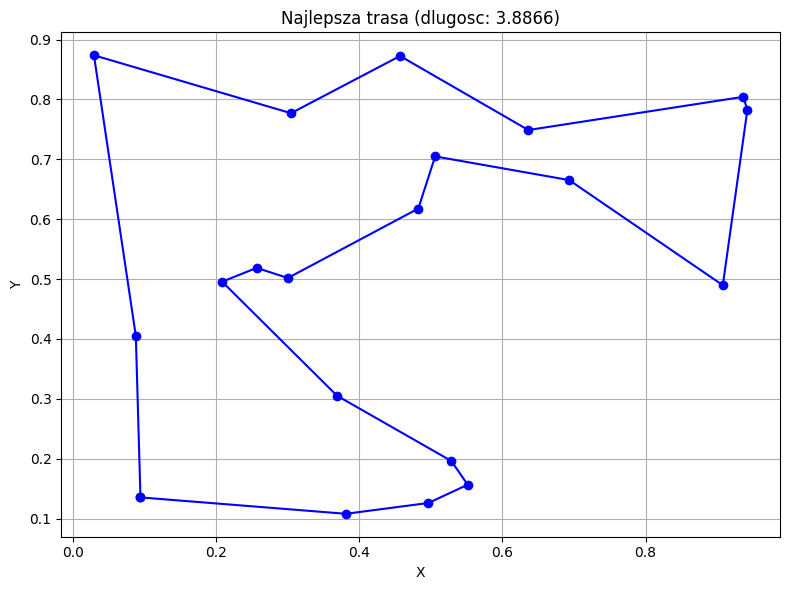

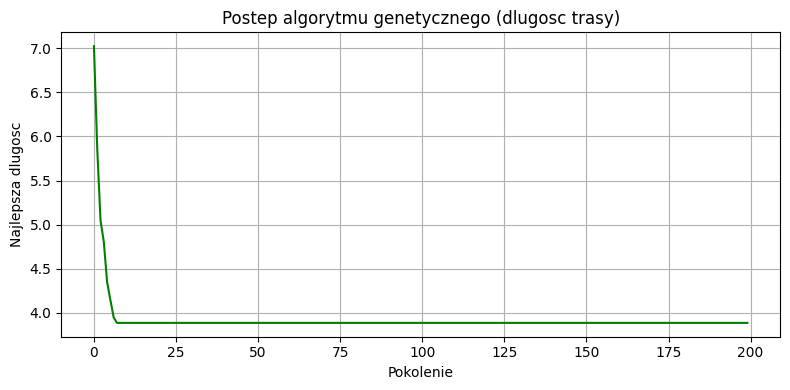

Eksperyment zakonczony. Czas wykonania: 25.1523 s




Eksperyment 47/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


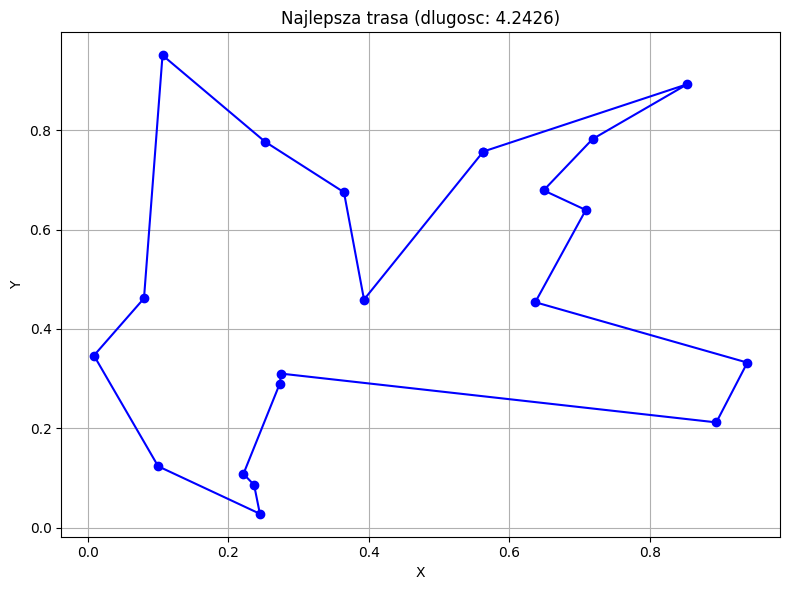

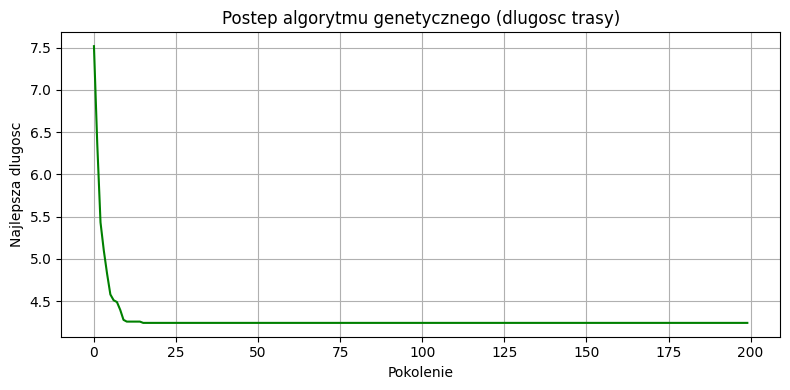

Eksperyment zakonczony. Czas wykonania: 27.6786 s




Eksperyment 48/72:
Start eksperymentu:
- Liczba miast      : 20
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


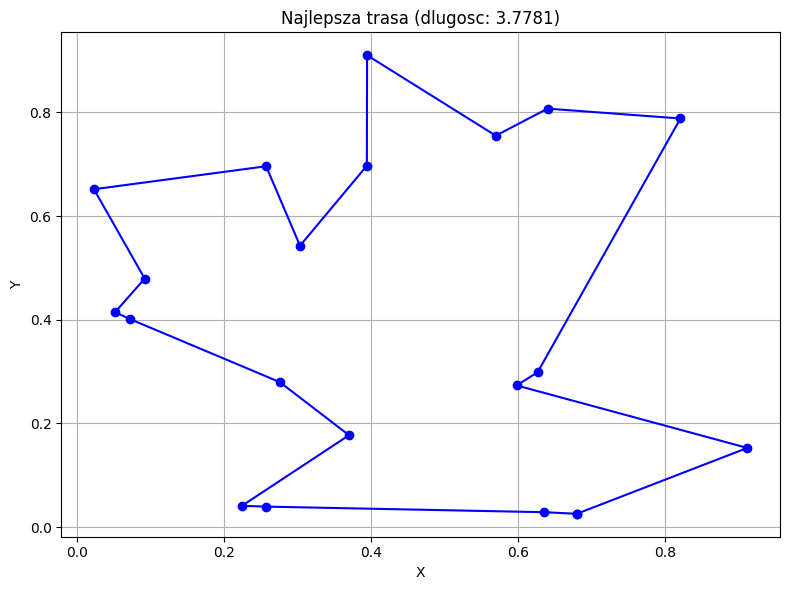

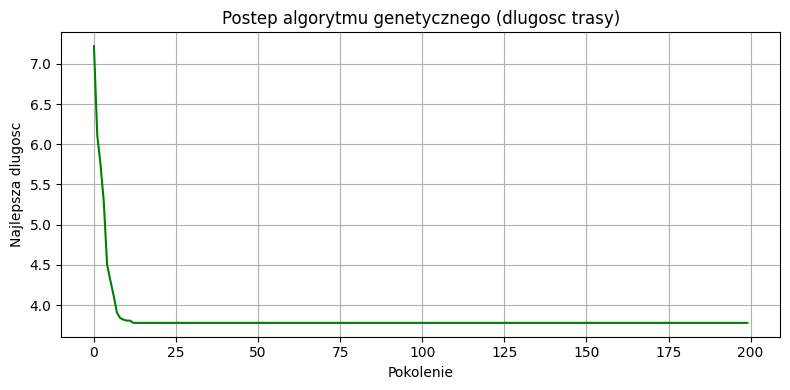

Eksperyment zakonczony. Czas wykonania: 20.8027 s




Eksperyment 49/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


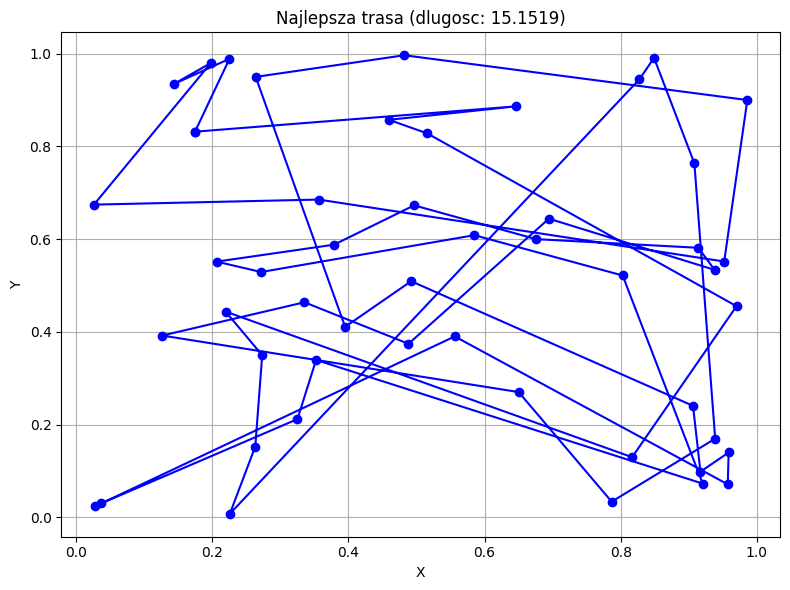

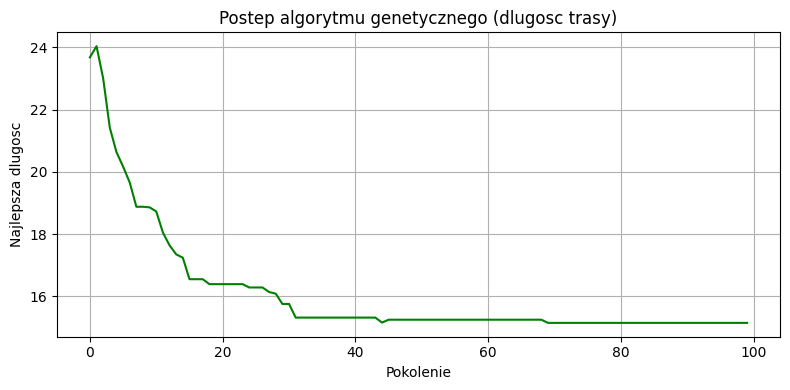

Eksperyment zakonczony. Czas wykonania: 1.3775 s




Eksperyment 50/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


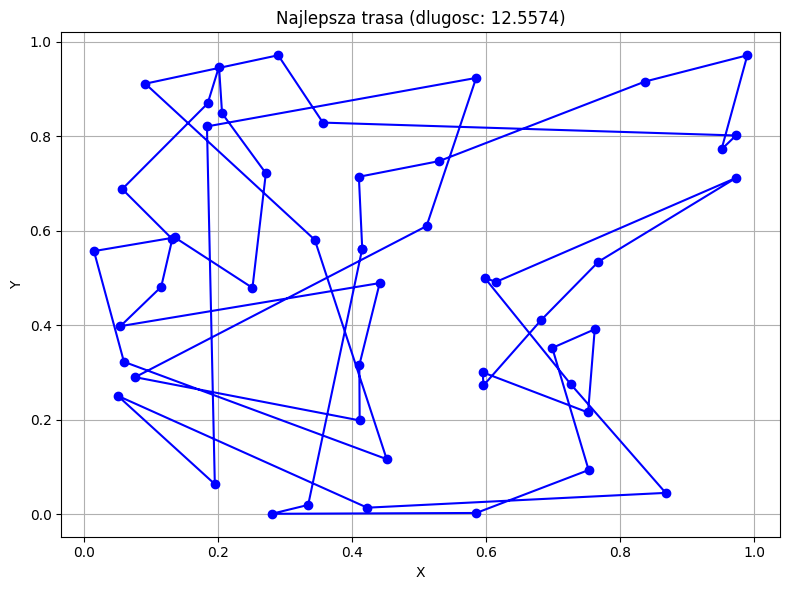

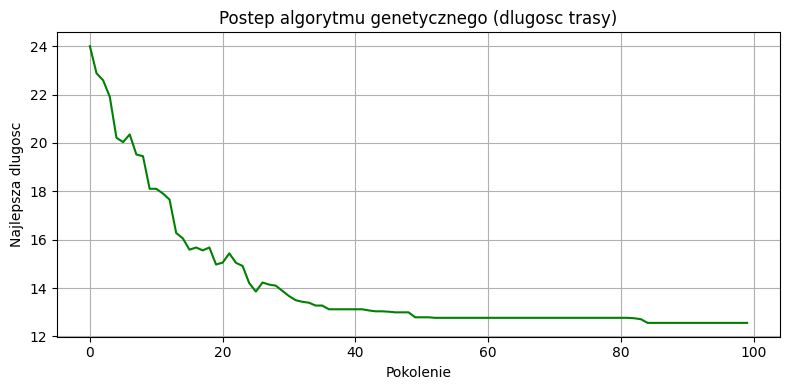

Eksperyment zakonczony. Czas wykonania: 1.5059 s




Eksperyment 51/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


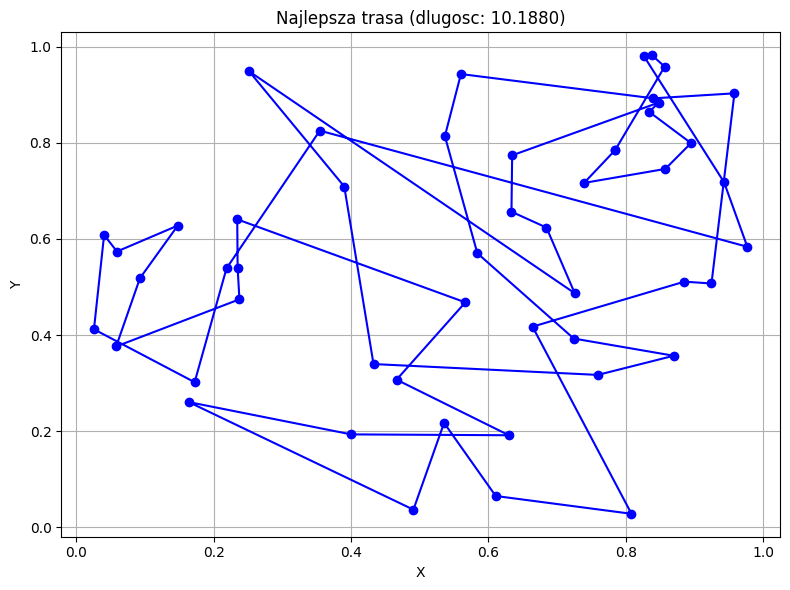

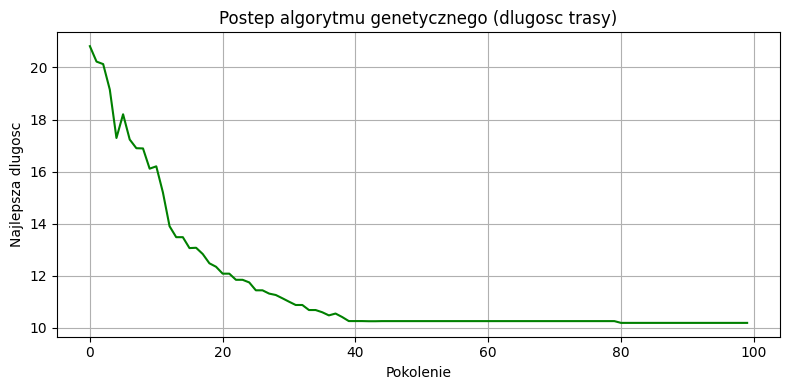

Eksperyment zakonczony. Czas wykonania: 1.5174 s




Eksperyment 52/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 50
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


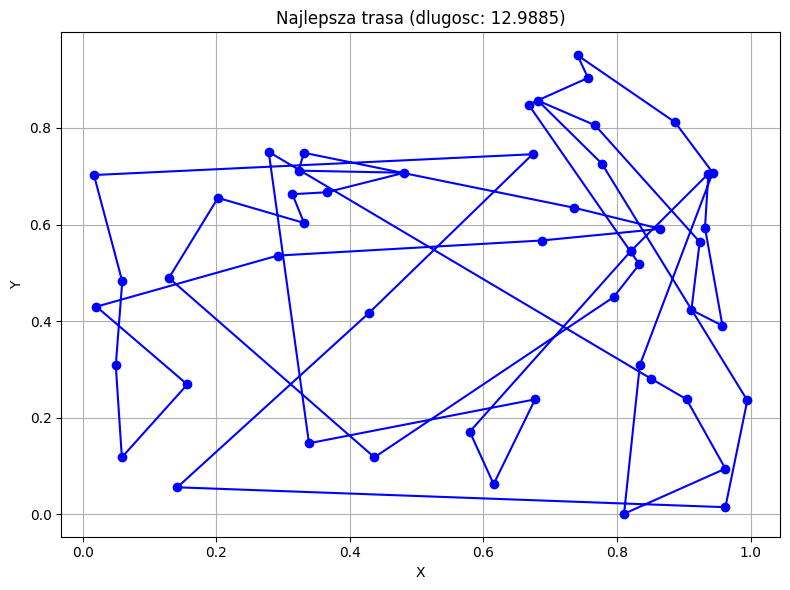

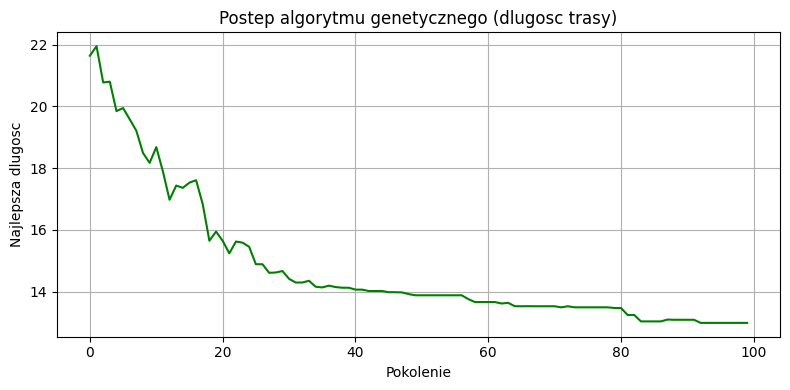

Eksperyment zakonczony. Czas wykonania: 1.4709 s




Eksperyment 53/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


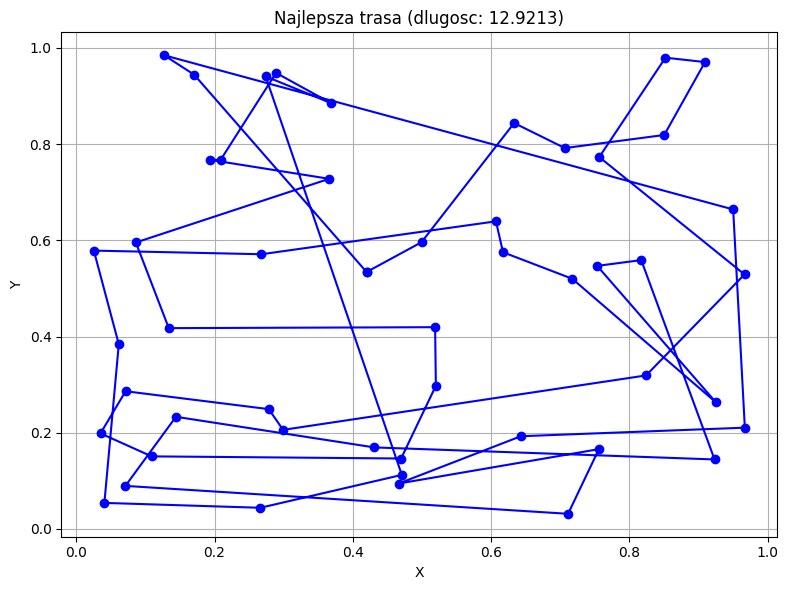

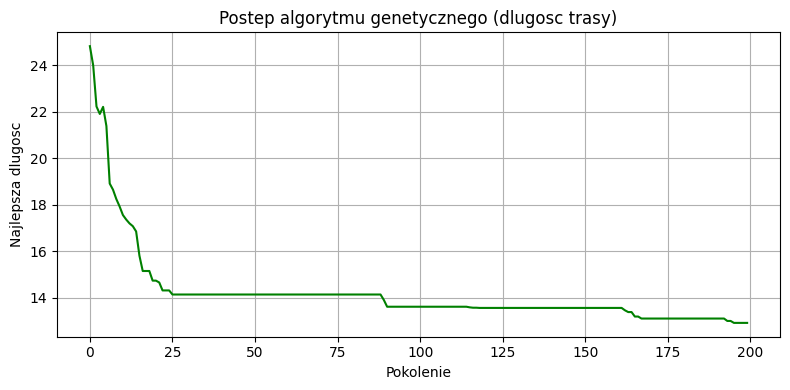

Eksperyment zakonczony. Czas wykonania: 3.4598 s




Eksperyment 54/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


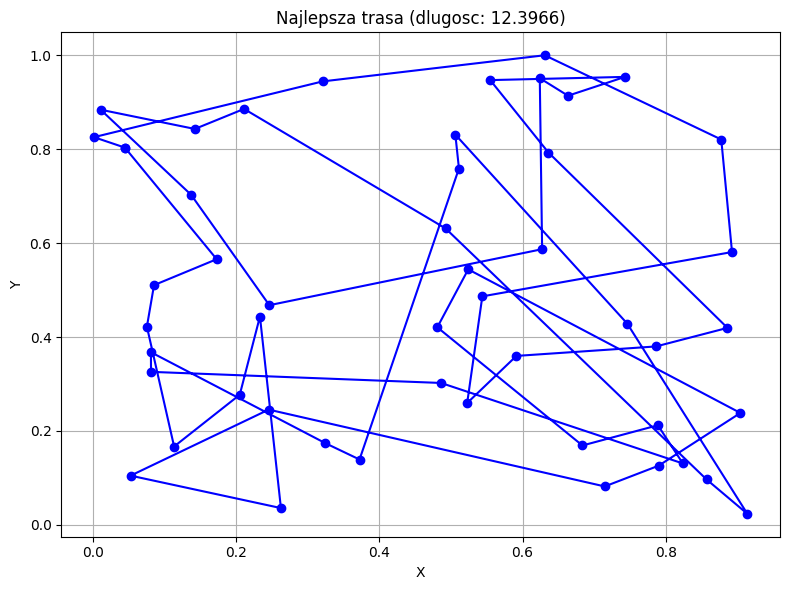

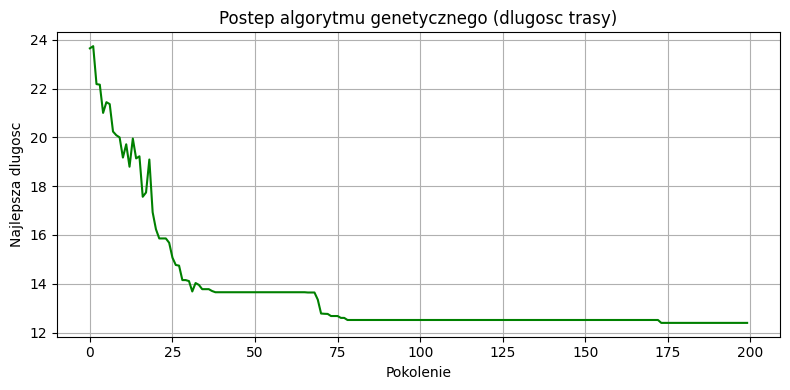

Eksperyment zakonczony. Czas wykonania: 4.4332 s




Eksperyment 55/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


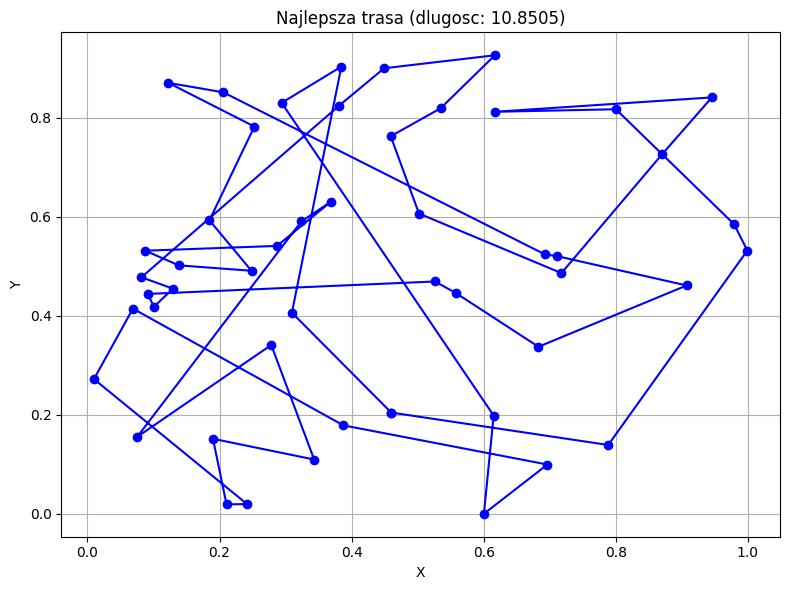

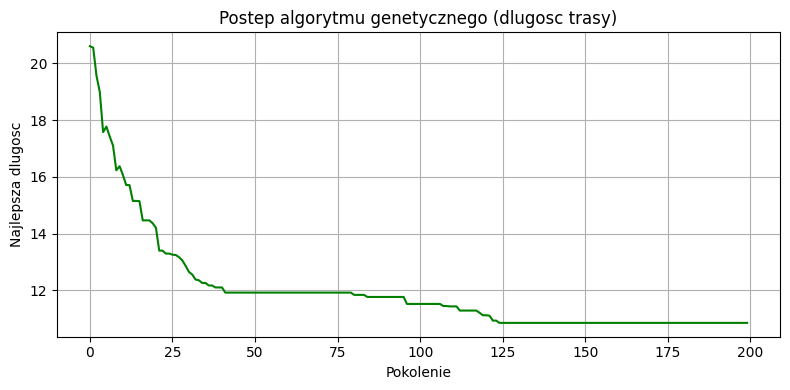

Eksperyment zakonczony. Czas wykonania: 3.7946 s




Eksperyment 56/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 50
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


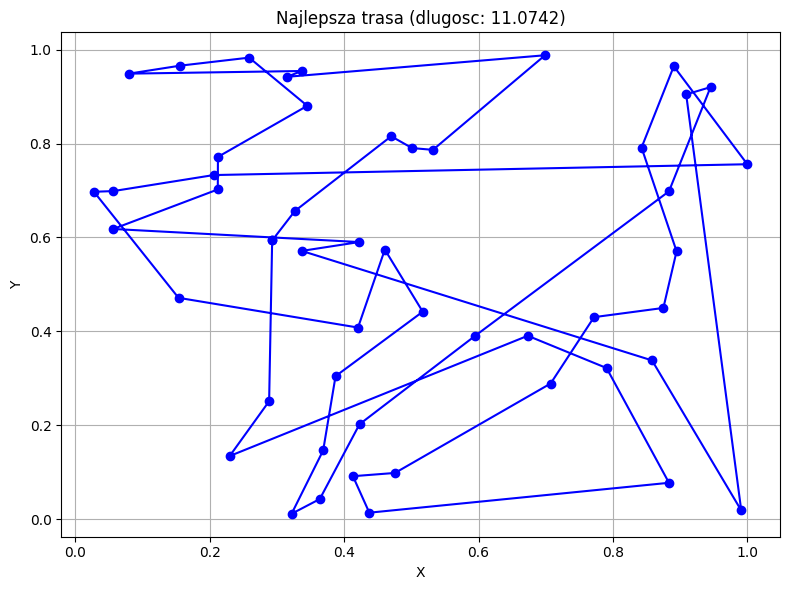

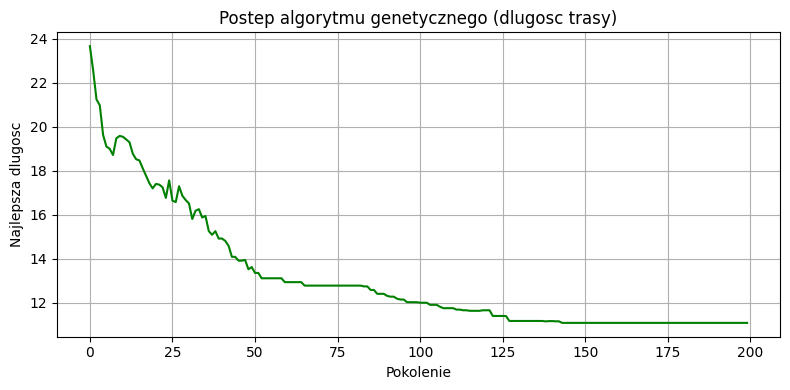

Eksperyment zakonczony. Czas wykonania: 3.3541 s




Eksperyment 57/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


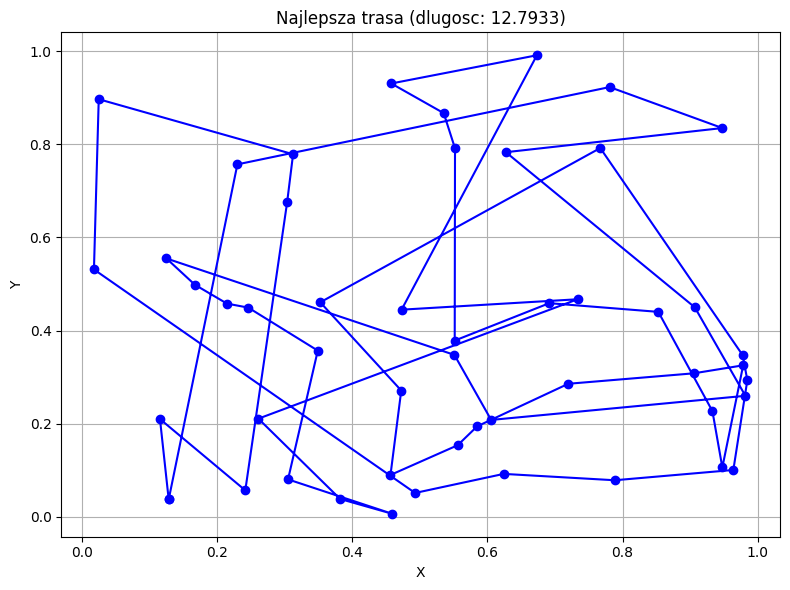

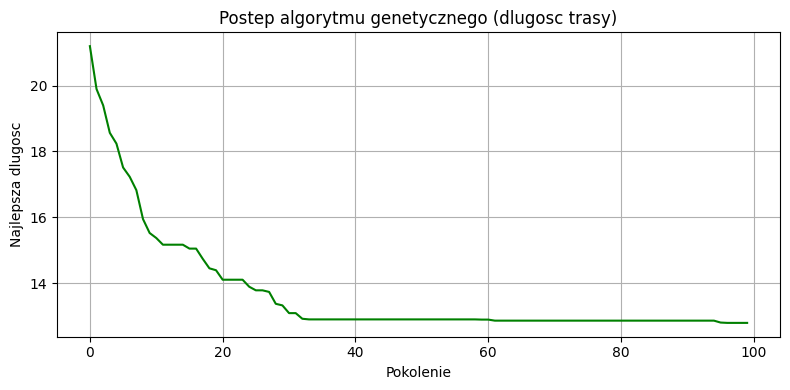

Eksperyment zakonczony. Czas wykonania: 2.6779 s




Eksperyment 58/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


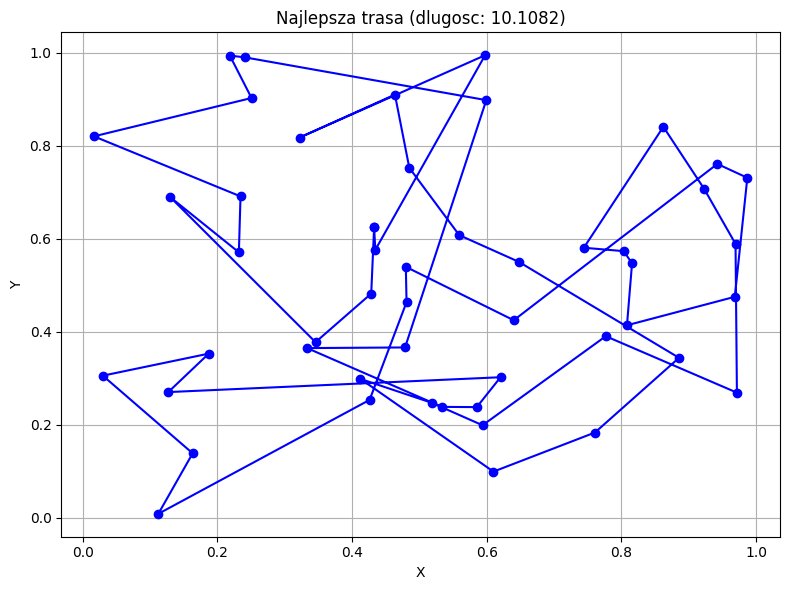

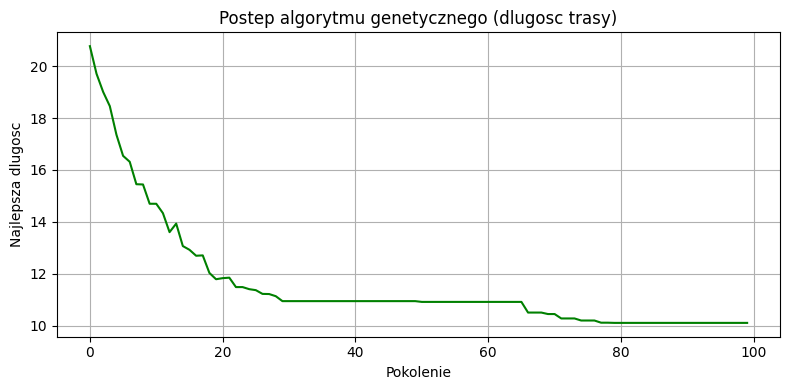

Eksperyment zakonczony. Czas wykonania: 2.9759 s




Eksperyment 59/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


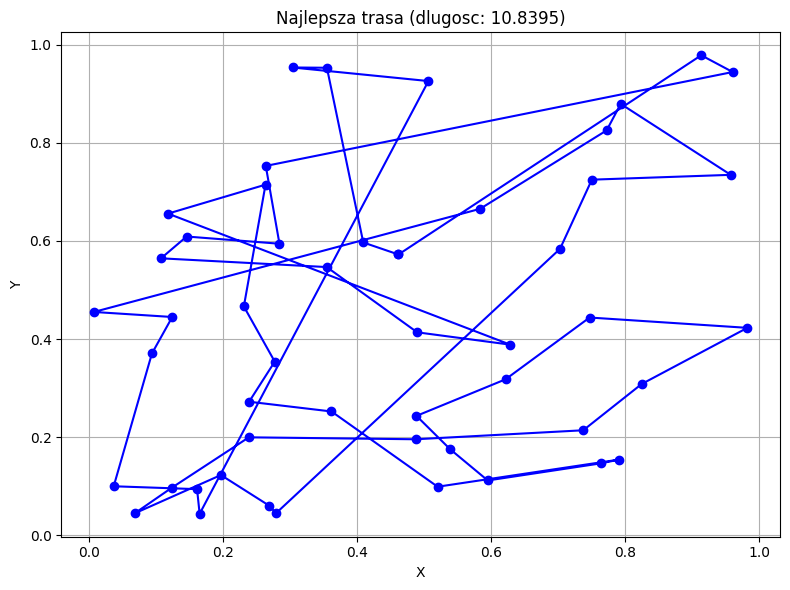

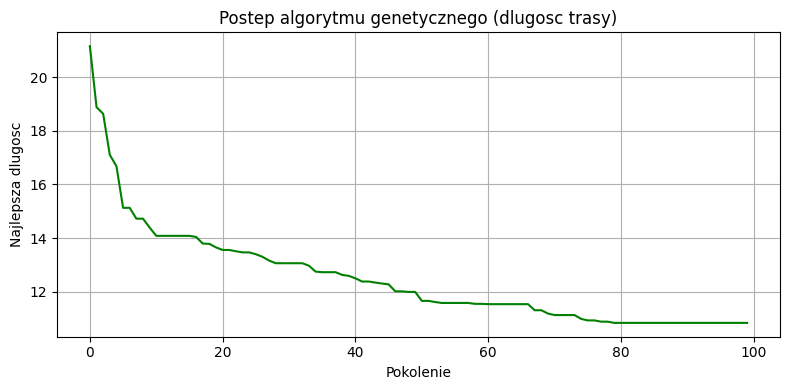

Eksperyment zakonczony. Czas wykonania: 2.9644 s




Eksperyment 60/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 100
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


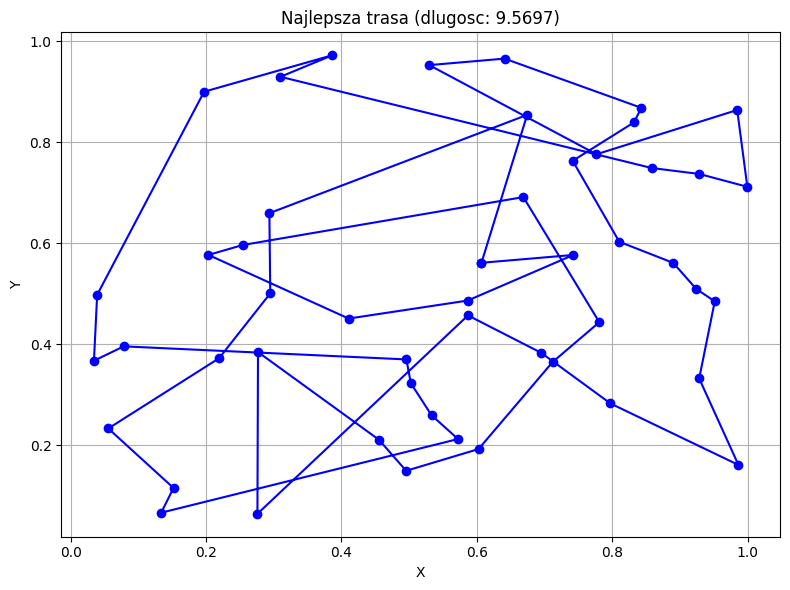

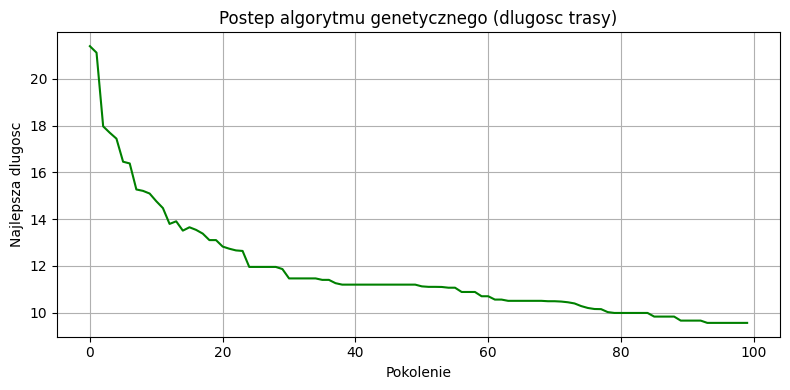

Eksperyment zakonczony. Czas wykonania: 2.9649 s




Eksperyment 61/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


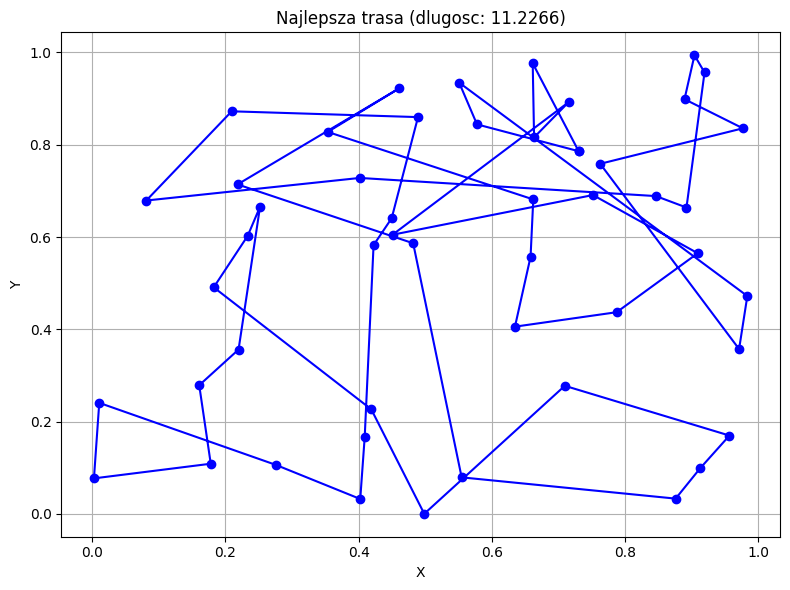

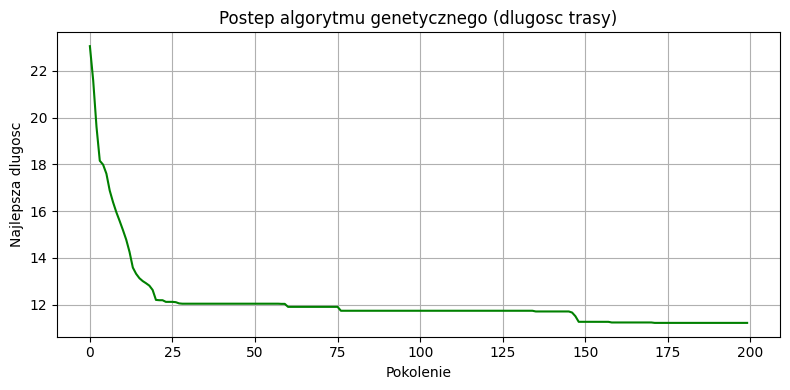

Eksperyment zakonczony. Czas wykonania: 5.0915 s




Eksperyment 62/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


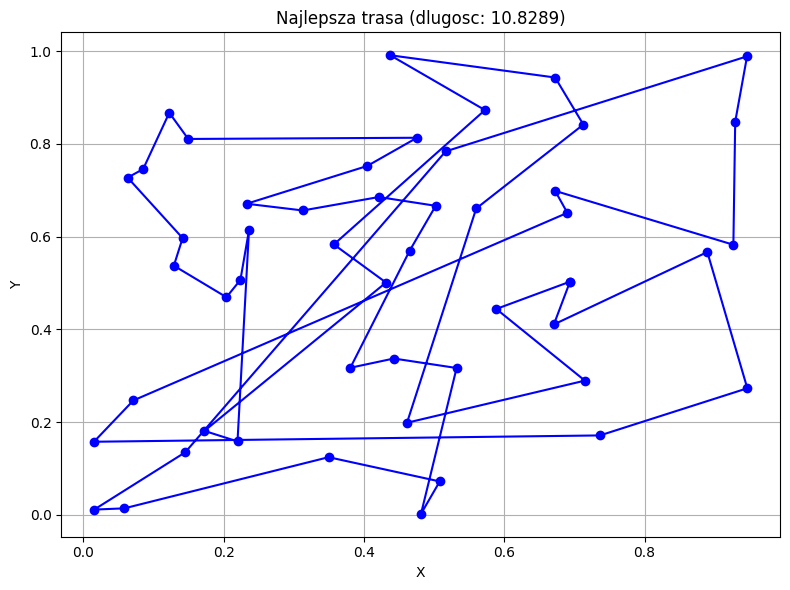

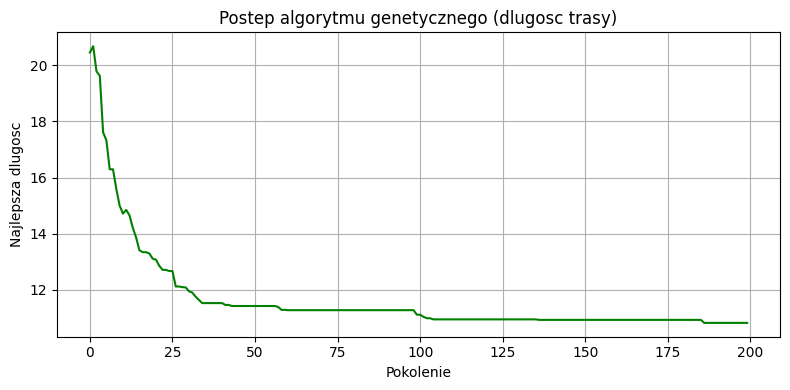

Eksperyment zakonczony. Czas wykonania: 5.4502 s




Eksperyment 63/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


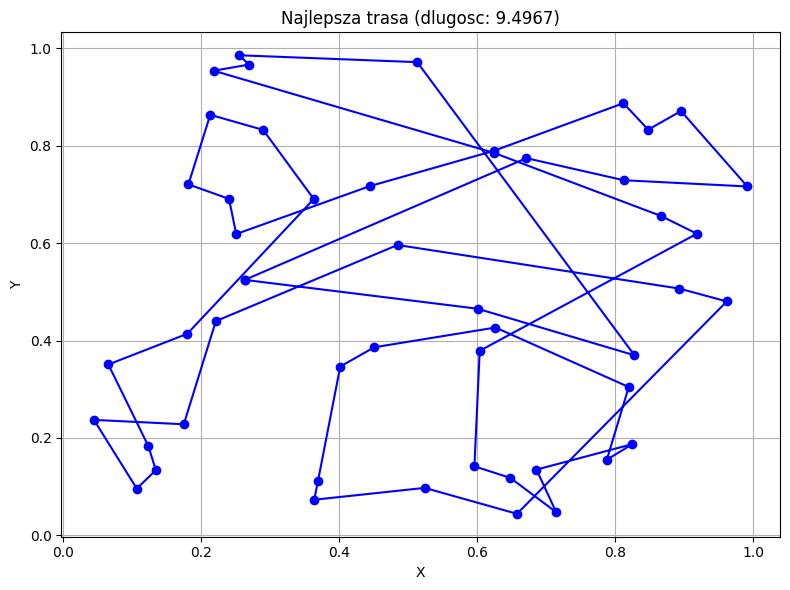

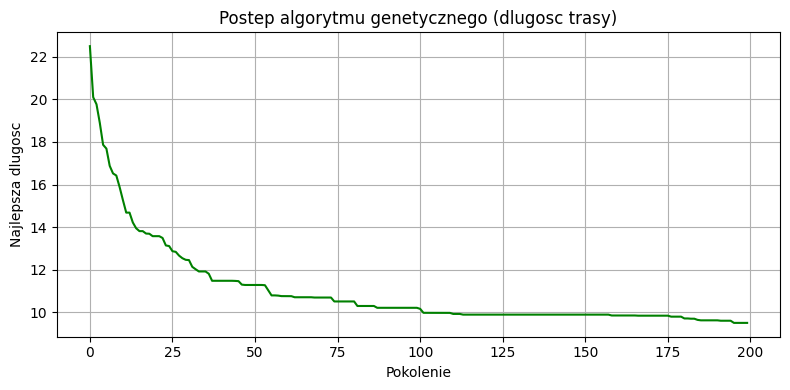

Eksperyment zakonczony. Czas wykonania: 5.5601 s




Eksperyment 64/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 100
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


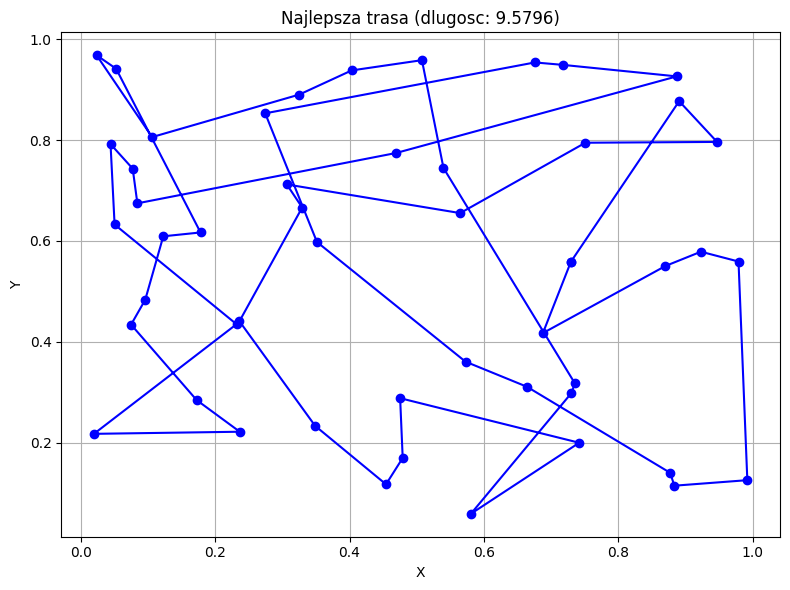

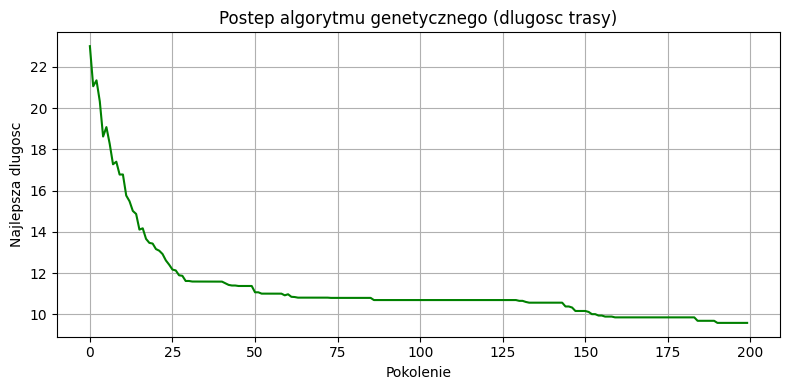

Eksperyment zakonczony. Czas wykonania: 6.2496 s




Eksperyment 65/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


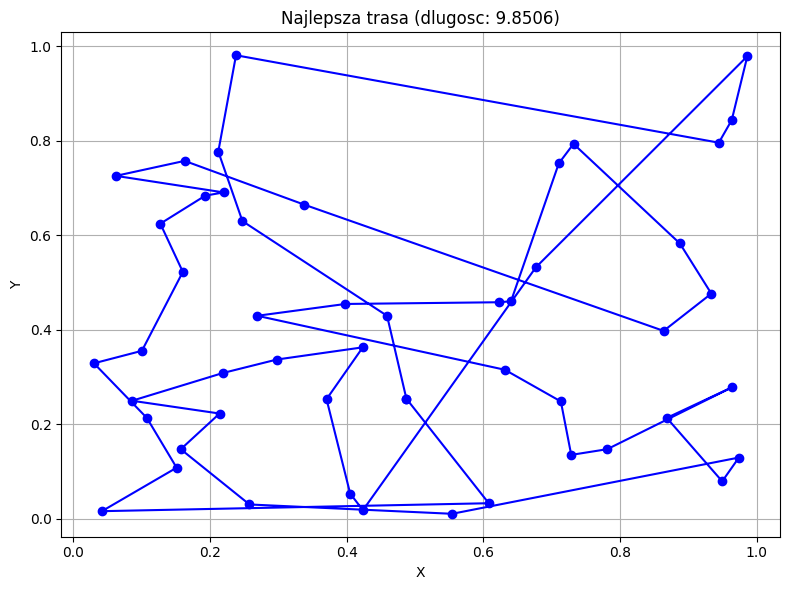

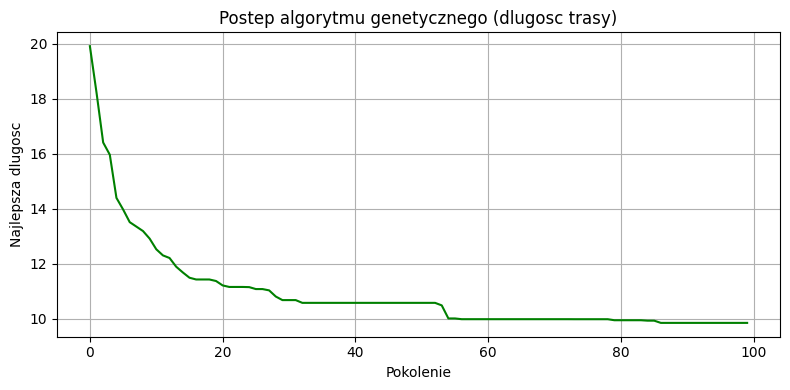

Eksperyment zakonczony. Czas wykonania: 37.1688 s




Eksperyment 66/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


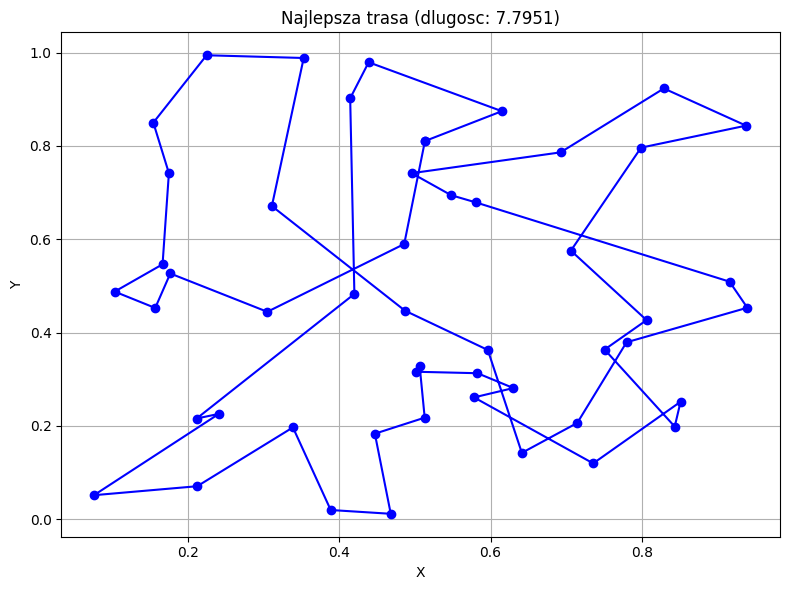

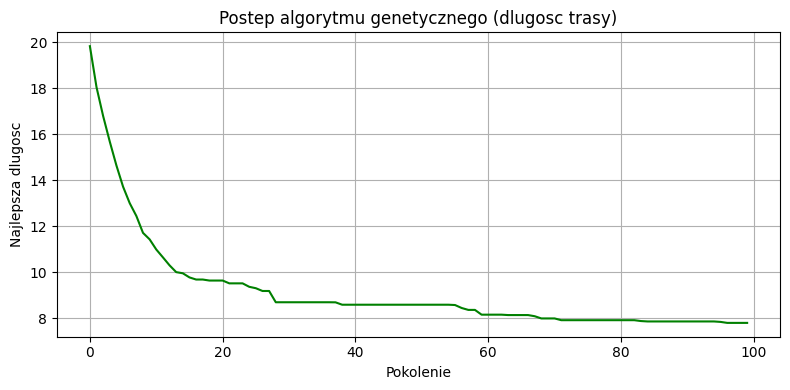

Eksperyment zakonczony. Czas wykonania: 35.3886 s




Eksperyment 67/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


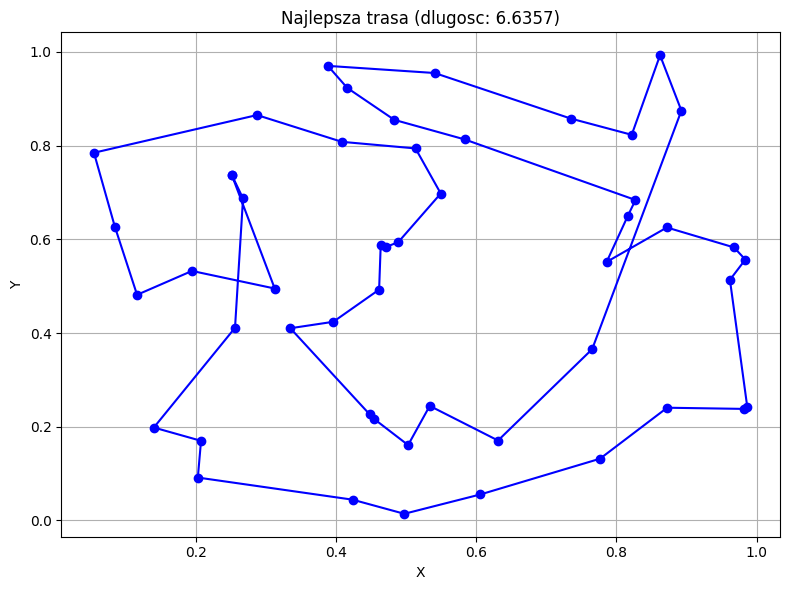

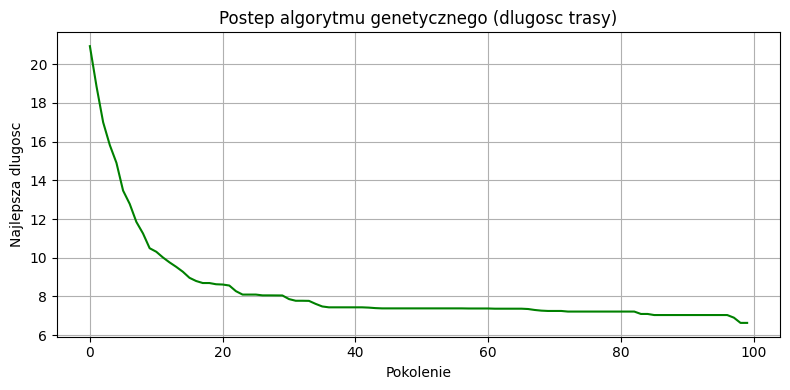

Eksperyment zakonczony. Czas wykonania: 34.9658 s




Eksperyment 68/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 1000
- Pokolenia         : 100
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


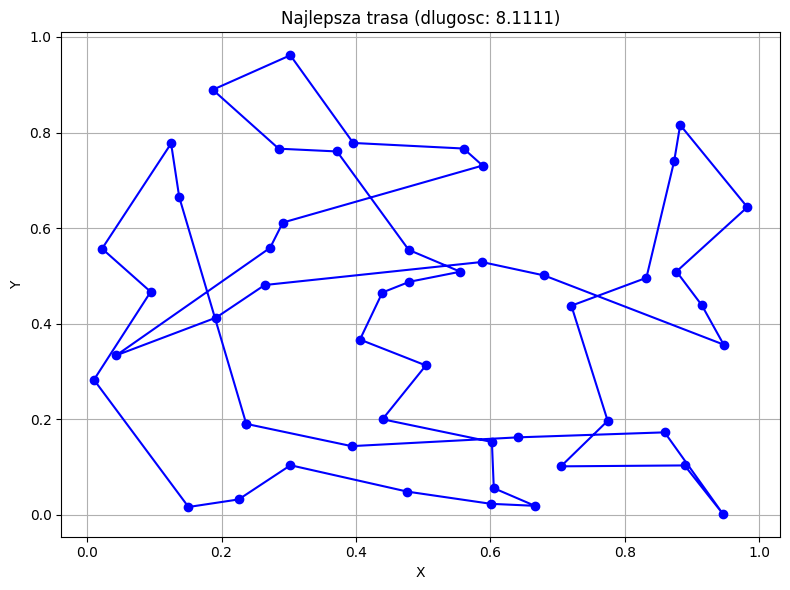

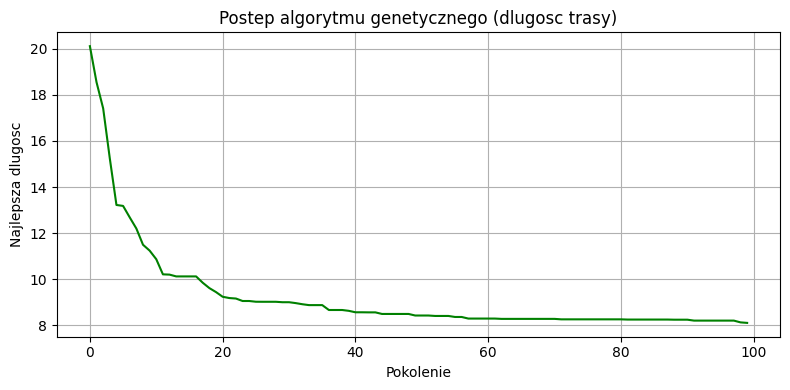

Eksperyment zakonczony. Czas wykonania: 36.0188 s




Eksperyment 69/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 10


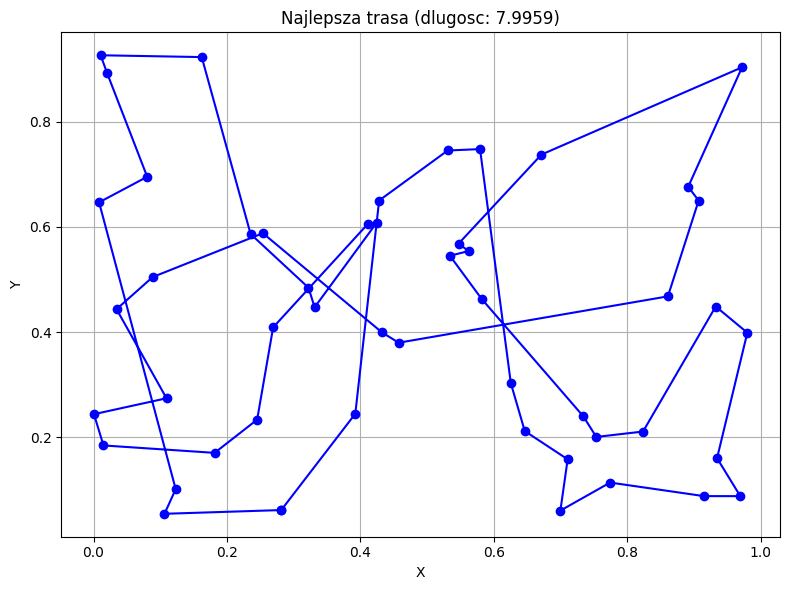

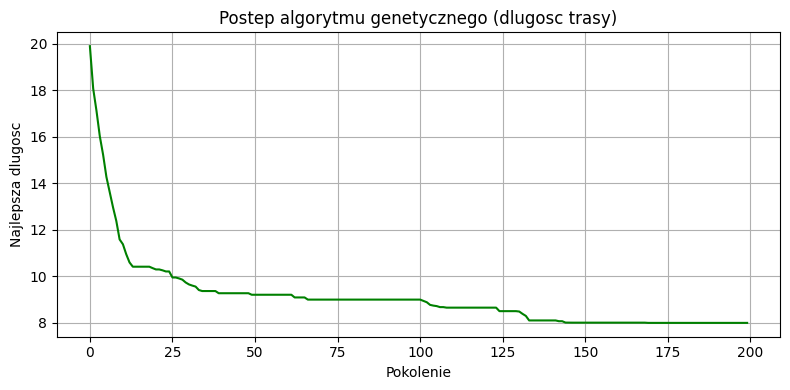

Eksperyment zakonczony. Czas wykonania: 69.3907 s




Eksperyment 70/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.01
- Liczba rodzicow   : 20


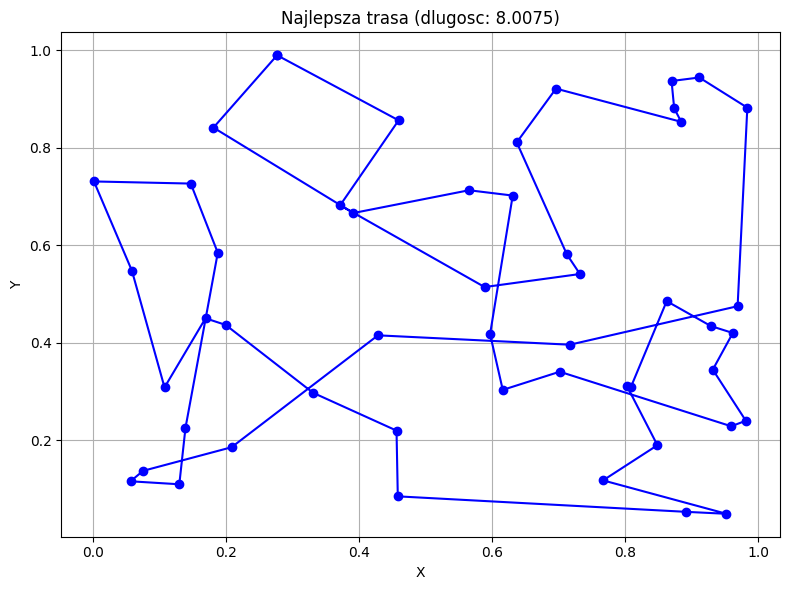

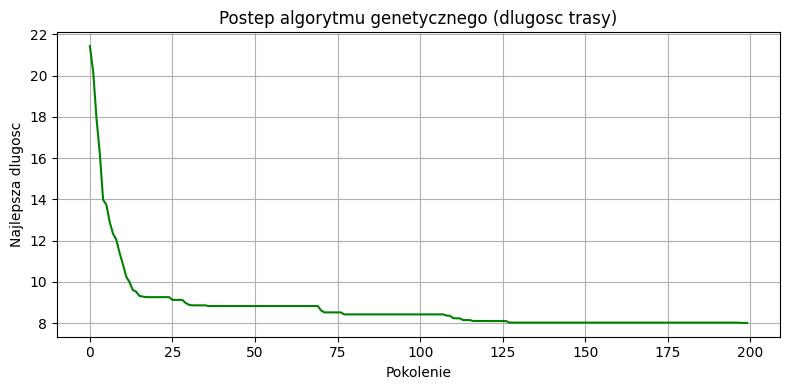

Eksperyment zakonczony. Czas wykonania: 71.5416 s




Eksperyment 71/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 10


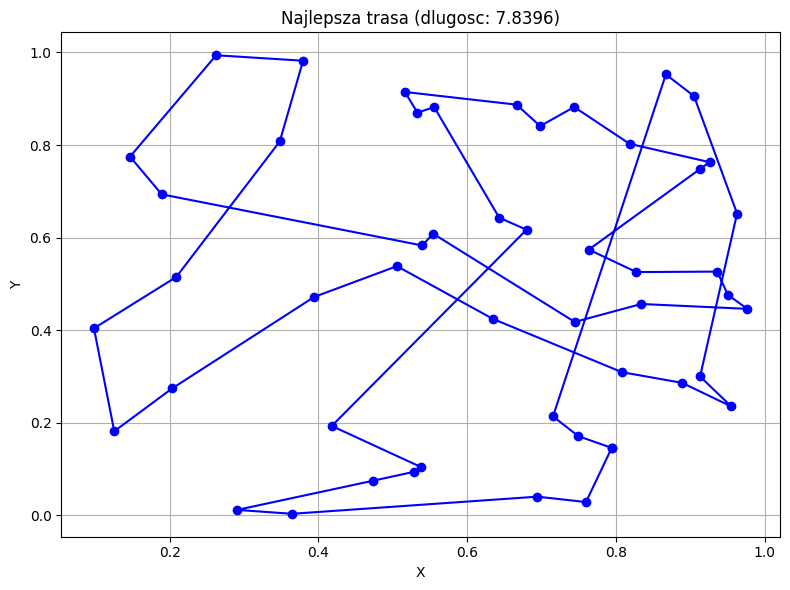

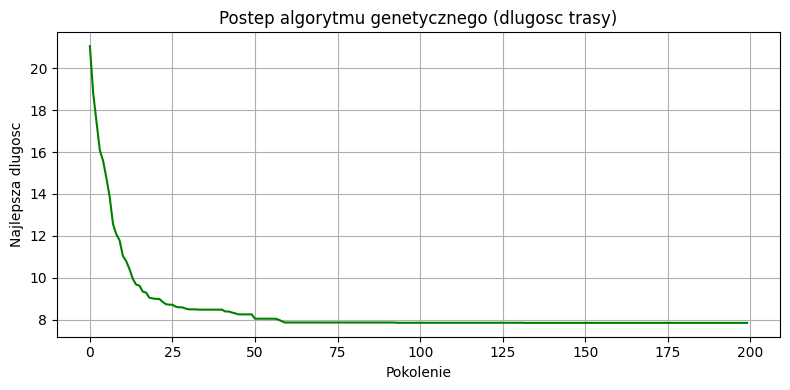

Eksperyment zakonczony. Czas wykonania: 72.9833 s




Eksperyment 72/72:
Start eksperymentu:
- Liczba miast      : 50
- Populacja         : 1000
- Pokolenia         : 200
- Wsp. mutacji      : 0.05
- Liczba rodzicow   : 20


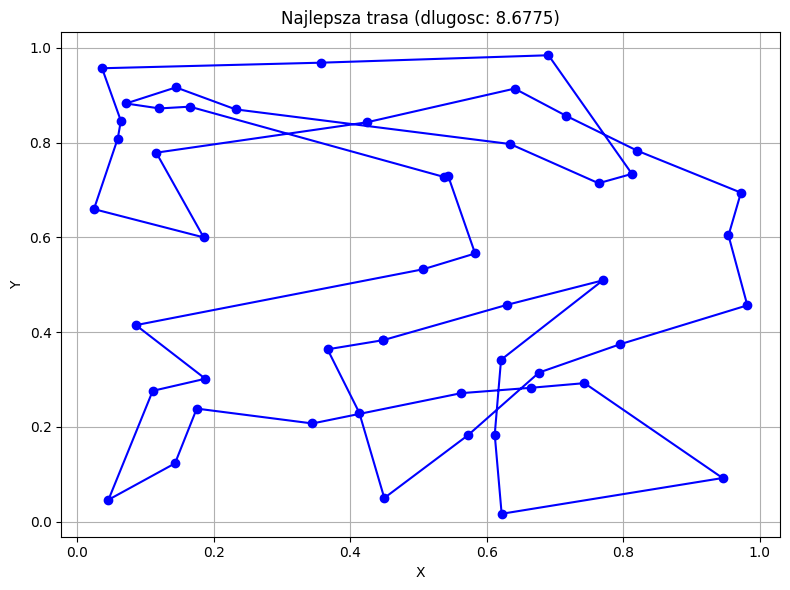

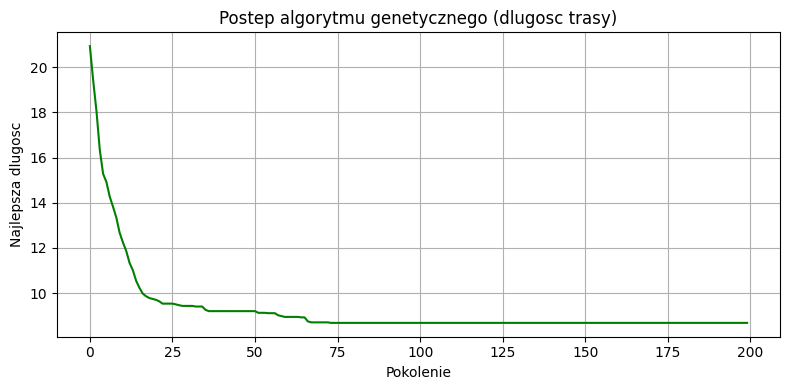

Eksperyment zakonczony. Czas wykonania: 81.8748 s





In [32]:
num_cities_list = [10, 20, 50]
pop_size_list = [50, 100, 1000]
generations_list = [100, 200]
mutation_rate_list = [0.01, 0.05]
num_parents_list = [10, 20]

# Przejscie przez wszystkie kombinacje
combinations = list(itertools.product(
    num_cities_list,
    pop_size_list,
    generations_list,
    mutation_rate_list,
    num_parents_list
))

# Uruchomienie eksperymentow
for index, params in enumerate(combinations):
    print(f"\nEksperyment {index + 1}/{len(combinations)}:")
    run_experiment(*params, plot=True, save=True, log=True)
    print("\n")